In [1]:
from abc import ABC, abstractmethod
from typing import Iterator, List, Optional, Union, Tuple
from collections import OrderedDict
import csv

import numpy as np
from tqdm import tqdm
from scipy.stats import t, spearmanr
from scipy.special import erfinv, softmax, logit, expit
from scipy.optimize import fmin
from sklearn.isotonic import IsotonicRegression


from catpred.data import MoleculeDataset, StandardScaler, MoleculeDataLoader
from catpred.models import MoleculeModel
from catpred.train.predict import predict
from catpred.multitask_utils import reshape_values, reshape_individual_preds

from catpred.uncertainty.uncertainty_calibrator import UncertaintyCalibrator
from catpred.train import evaluate_predictions

from catpred.uncertainty.uncertainty_predictor import build_uncertainty_predictor
from catpred.uncertainty.uncertainty_predictor import UncertaintyPredictor
from catpred.uncertainty import build_uncertainty_calibrator, UncertaintyEstimator, build_uncertainty_evaluator

from catpred.data import  get_data_from_smiles, StandardScaler, AtomBondScaler
from catpred.utils import load_args, load_checkpoint, load_scalers, makedirs, timeit, update_prediction_args
from catpred.features import set_extra_atom_fdim, set_extra_bond_fdim, set_reaction, set_explicit_h, set_adding_hs, set_keeping_atom_map, reset_featurization_parameters
from catpred.args import PredictArgs, TrainArgs
#from catpred.uncertainty import UncertaintyCalibrator, build_uncertainty_calibrator, UncertaintyEstimator, build_uncertainty_evaluator

def load_model(args: PredictArgs, generator: bool = False):
    """
    Function to load a model or ensemble of models from file. If generator is True, a generator of the respective model and scaler 
    objects is returned (memory efficient), else the full list (holding all models in memory, necessary for preloading).

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param generator: A boolean to return a generator instead of a list of models and scalers.
    :return: A tuple of updated prediction arguments, training arguments, a list or generator object of models, a list or 
                 generator object of scalers, the number of tasks and their respective names.
    """
    print('Loading training args')
    train_args = load_args(args.checkpoint_paths[0])
    if args.pretrained_egnn_feats_path: 
        pretrained_egnn_feats_path = args.pretrained_egnn_feats_path
    else:
        pretrained_egnn_feats_path = train_args.pretrained_egnn_feats_path
    num_tasks, task_names = train_args.num_tasks, train_args.task_names
    update_prediction_args(predict_args=args, train_args=train_args)
    print('Loading models')
    args: Union[PredictArgs, TrainArgs]
    
    
    # Load model and scalers
    models = (
        load_checkpoint(checkpoint_path, pretrained_egnn_feats_path = pretrained_egnn_feats_path, device=args.device) for checkpoint_path in args.checkpoint_paths
    )
    scalers = (
        load_scalers(checkpoint_path) for checkpoint_path in args.checkpoint_paths
    )
    if not generator:
        models = list(models)
        scalers = list(scalers)

    return args, train_args, models, scalers, num_tasks, task_names


def load_data(args: PredictArgs, smiles: List[List[str]]):
    """
    Function to load data from a list of smiles or a file.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param smiles: A list of list of smiles, or None if data is to be read from file
    :return: A tuple of a :class:`~catpred.data.MoleculeDataset` containing all datapoints, a :class:`~catpred.data.MoleculeDataset` containing only valid datapoints,
                 a :class:`~catpred.data.MoleculeDataLoader` and a dictionary mapping full to valid indices.
    """
    print("Loading data")
    if smiles is not None:
        full_data = get_data_from_smiles(
            smiles=smiles,
            skip_invalid_smiles=True,
            features_generator=args.features_generator,
        )
    else:
        full_data = get_data(
            protein_records_path=args.protein_records_path,
            vocabulary_path=args.vocabulary_path,
            path=args.test_path,
            smiles_columns=args.smiles_columns,
            target_columns=[],
            ignore_columns=[],
            skip_invalid_smiles=True,
            args=args,
            store_row=not args.drop_extra_columns,
        )

    print("Validating SMILES")
    full_to_valid_indices = {}
    valid_index = 0
    for full_index in range(len(full_data)):
        if all(mol is not None for mol in full_data[full_index].mol):
            full_to_valid_indices[full_index] = valid_index
            valid_index += 1

    test_data = MoleculeDataset(
        [full_data[i] for i in sorted(full_to_valid_indices.keys())]
    )

    print(f"Test size = {len(test_data):,}")

    # Create data loader
    test_data_loader = MoleculeDataLoader(
        dataset=test_data, batch_size=args.batch_size, num_workers=args.num_workers
    )

    return full_data, test_data, test_data_loader, full_to_valid_indices


def set_features(args: PredictArgs, train_args: TrainArgs):
    """
    Function to set extra options.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param train_args: A :class:`~catpred.args.TrainArgs` object containing arguments for training the model.
    """
    reset_featurization_parameters()

    if args.atom_descriptors == "feature":
        set_extra_atom_fdim(train_args.atom_features_size)

    if args.bond_descriptors == "feature":
        set_extra_bond_fdim(train_args.bond_features_size)

    # set explicit H option and reaction option
    set_explicit_h(train_args.explicit_h)
    set_adding_hs(args.adding_h)
    set_keeping_atom_map(args.keeping_atom_map)
    if train_args.reaction:
        set_reaction(train_args.reaction, train_args.reaction_mode)
    elif train_args.reaction_solvent:
        set_reaction(True, train_args.reaction_mode)


def predict_and_save(
    args: PredictArgs,
    train_args: TrainArgs,
    test_data: MoleculeDataset,
    task_names: List[str],
    num_tasks: int,
    test_data_loader: MoleculeDataLoader,
    full_data: MoleculeDataset,
    full_to_valid_indices: dict,
    models: List[MoleculeModel],
    scalers: List[Union[StandardScaler, AtomBondScaler]],
    num_models: int,
    calibrator: UncertaintyCalibrator = None,
    return_invalid_smiles: bool = False,
    save_results: bool = True,
):
    """
    Function to predict with a model and save the predictions to file.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param train_args: A :class:`~catpred.args.TrainArgs` object containing arguments for training the model.
    :param test_data: A :class:`~catpred.data.MoleculeDataset` containing valid datapoints.
    :param task_names: A list of task names.
    :param num_tasks: Number of tasks.
    :param test_data_loader: A :class:`~catpred.data.MoleculeDataLoader` to load the test data.
    :param full_data:  A :class:`~catpred.data.MoleculeDataset` containing all (valid and invalid) datapoints.
    :param full_to_valid_indices: A dictionary dictionary mapping full to valid indices.
    :param models: A list or generator object of :class:`~catpred.models.MoleculeModel`\ s.
    :param scalers: A list or generator object of :class:`~catpred.features.scaler.StandardScaler` objects.
    :param num_models: The number of models included in the models and scalers input.
    :param calibrator: A :class: `~catpred.uncertainty.UncertaintyCalibrator` object, for use in calibrating uncertainty predictions.
    :param return_invalid_smiles: Whether to return predictions of "Invalid SMILES" for invalid SMILES, otherwise will skip them in returned predictions.
    :param save_results: Whether to save the predictions in a csv. Function returns the predictions regardless.
    :return: A list of lists of target predictions.
    """
    estimator = UncertaintyEstimator(
        test_data=test_data,
        test_data_loader=test_data_loader,
        uncertainty_method=args.uncertainty_method,
        models=models,
        scalers=scalers,
        num_models=num_models,
        dataset_type=args.dataset_type,
        loss_function=args.loss_function,
        uncertainty_dropout_p=args.uncertainty_dropout_p,
        dropout_sampling_size=args.dropout_sampling_size,
        individual_ensemble_predictions=args.individual_ensemble_predictions,
        spectra_phase_mask=getattr(train_args, "spectra_phase_mask", None),
    )

    preds, unc = estimator.calculate_uncertainty(
        calibrator=calibrator
    )  # preds and unc are lists of shape(data,tasks)

    if calibrator is not None and args.is_atom_bond_targets and args.calibration_method == "isotonic":
        unc = reshape_values(unc, test_data, len(args.atom_targets), len(args.bond_targets), num_tasks)

    if args.individual_ensemble_predictions:
        individual_preds = (
            estimator.individual_predictions()
        )  # shape(data, tasks, ensemble) or (data, tasks, classes, ensemble)

    if args.evaluation_methods is not None:

        evaluation_data = get_data(
            protein_records_path = args.protein_records_path,
            path=args.test_path,
            smiles_columns=args.smiles_columns,
            target_columns=task_names,
            args=args,
            features_path=args.features_path,
            features_generator=args.features_generator,
            phase_features_path=args.phase_features_path,
            atom_descriptors_path=args.atom_descriptors_path,
            bond_descriptors_path=args.bond_descriptors_path,
            max_data_size=args.max_data_size,
            loss_function=args.loss_function,
        )

        evaluators = []
        for evaluation_method in args.evaluation_methods:
            evaluator = build_uncertainty_evaluator(
                evaluation_method=evaluation_method,
                calibration_method=args.calibration_method,
                uncertainty_method=args.uncertainty_method,
                dataset_type=args.dataset_type,
                loss_function=args.loss_function,
                calibrator=calibrator,
                is_atom_bond_targets=args.is_atom_bond_targets,
            )
            evaluators.append(evaluator)
    else:
        evaluators = None

    if evaluators is not None:
        evaluations = []
        print(f"Evaluating uncertainty for tasks {task_names}")
        for evaluator in evaluators:
            evaluation = evaluator.evaluate(
                targets=evaluation_data.targets(), preds=preds, uncertainties=unc, mask=evaluation_data.mask()
            )
            evaluations.append(evaluation)
            print(
                f"Using evaluation method {evaluator.evaluation_method}: {evaluation}"
            )
    else:
        evaluations = None

    # Save results
    if save_results:
        print(f"Saving predictions to {args.preds_path}")
        assert len(test_data) == len(preds)
        assert len(test_data) == len(unc)

        makedirs(args.preds_path, isfile=True)

        # Set multiclass column names, update num_tasks definitions
        if args.dataset_type == "multiclass":
            original_task_names = task_names
            task_names = [
                f"{name}_class_{i}"
                for name in task_names
                for i in range(args.multiclass_num_classes)
            ]
            num_tasks = num_tasks * args.multiclass_num_classes
        if args.uncertainty_method == "spectra_roundrobin":
            num_unc_tasks = 1
        else:
            num_unc_tasks = num_tasks

        # Copy predictions over to full_data
        for full_index, datapoint in enumerate(full_data):
            valid_index = full_to_valid_indices.get(full_index, None)
            if valid_index is not None:
                d_preds = preds[valid_index]
                d_unc = unc[valid_index]
                if args.individual_ensemble_predictions:
                    ind_preds = individual_preds[valid_index]
            else:
                d_preds = ["Invalid SMILES"] * num_tasks
                d_unc = ["Invalid SMILES"] * num_unc_tasks
                if args.individual_ensemble_predictions:
                    ind_preds = [["Invalid SMILES"] * len(args.checkpoint_paths)] * num_tasks
            # Reshape multiclass to merge task and class dimension, with updated num_tasks
            if args.dataset_type == "multiclass":
                d_preds = np.array(d_preds).reshape((num_tasks))
                d_unc = np.array(d_unc).reshape((num_unc_tasks))
                if args.individual_ensemble_predictions:
                    ind_preds = ind_preds.reshape(
                        (num_tasks, len(args.checkpoint_paths))
                    )

            # If extra columns have been dropped, add back in SMILES columns
            if args.drop_extra_columns:
                datapoint.row = OrderedDict()

                smiles_columns = args.smiles_columns

                for column, smiles in zip(smiles_columns, datapoint.smiles):
                    datapoint.row[column] = smiles

            # Add predictions columns
            if args.uncertainty_method == "spectra_roundrobin":
                unc_names = [estimator.label]
            else:
                unc_names = [name + f"_{estimator.label}" for name in task_names]

            for pred_name, unc_name, pred, un in zip(
                task_names, unc_names, d_preds, d_unc
            ):
                datapoint.row[pred_name] = pred
                if args.uncertainty_method is not None:
                    datapoint.row[unc_name] = un
            if args.individual_ensemble_predictions:
                for pred_name, model_preds in zip(task_names, ind_preds):
                    for idx, pred in enumerate(model_preds):
                        datapoint.row[pred_name + f"_model_{idx}"] = pred

        # Save
        with open(args.preds_path, 'w', newline="") as f:
            writer = csv.DictWriter(f, fieldnames=full_data[0].row.keys())
            writer.writeheader()

            for datapoint in full_data:
                writer.writerow(datapoint.row)

        if evaluations is not None and args.evaluation_scores_path is not None:
            print(f"Saving uncertainty evaluations to {args.evaluation_scores_path}")
            if args.dataset_type == "multiclass":
                task_names = original_task_names
            with open(args.evaluation_scores_path, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["evaluation_method"] + task_names)
                for i, evaluation_method in enumerate(args.evaluation_methods):
                    writer.writerow([evaluation_method] + evaluations[i])

    if return_invalid_smiles:
        full_preds = []
        full_unc = []
        for full_index in range(len(full_data)):
            valid_index = full_to_valid_indices.get(full_index, None)
            if valid_index is not None:
                pred = preds[valid_index]
                un = unc[valid_index]
            else:
                pred = ["Invalid SMILES"] * num_tasks
                un = ["Invalid SMILES"] * num_unc_tasks
            full_preds.append(pred)
            full_unc.append(un)
        return full_preds, full_unc
    else:
        return preds, unc


@timeit()
def make_predictions(
    args: PredictArgs,
    smiles: List[List[str]] = None,
    model_objects: Tuple[
        PredictArgs,
        TrainArgs,
        List[MoleculeModel],
        List[Union[StandardScaler, AtomBondScaler]],
        int,
        List[str],
    ] = None,
    calibrator: UncertaintyCalibrator = None,
    return_invalid_smiles: bool = True,
    return_index_dict: bool = False,
    return_uncertainty: bool = False,
) -> List[List[Optional[float]]]:
    """
    Loads data and a trained model and uses the model to make predictions on the data.

    If SMILES are provided, then makes predictions on smiles.
    Otherwise makes predictions on :code:`args.test_data`.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                loading data and a model and making predictions.
    :param smiles: List of list of SMILES to make predictions on.
    :param model_objects: Tuple of output of load_model function which can be called separately outside this function. Preloaded model objects should have
                used the non-generator option for load_model if the objects are to be used multiple times or are intended to be used for calibration as well.
    :param calibrator: A :class: `~catpred.uncertainty.UncertaintyCalibrator` object, for use in calibrating uncertainty predictions.
                Can be preloaded and provided as a function input or constructed within the function from arguments. The models and scalers used
                to initiate the calibrator must be lists instead of generators if the same calibrator is to be used multiple times or
                if the same models and scalers objects are also part of the provided model_objects input.
    :param return_invalid_smiles: Whether to return predictions of "Invalid SMILES" for invalid SMILES, otherwise will skip them in returned predictions.
    :param return_index_dict: Whether to return the prediction results as a dictionary keyed from the initial data indexes.
    :param return_uncertainty: Whether to return uncertainty predictions alongside the model value predictions.
    :return: A list of lists of target predictions. If returning uncertainty, a tuple containing first prediction values then uncertainty estimates.
    """
    if model_objects:
        (
            args,
            train_args,
            models,
            scalers,
            num_tasks,
            task_names,
        ) = model_objects
    else:
        (
            args,
            train_args,
            models,
            scalers,
            num_tasks,
            task_names,
        ) = load_model(args, generator=True)

    num_models = len(args.checkpoint_paths)

    set_features(args, train_args)

    # Note: to get the invalid SMILES for your data, use the get_invalid_smiles_from_file or get_invalid_smiles_from_list functions from data/utils.py
    full_data, test_data, test_data_loader, full_to_valid_indices = load_data(
        args, smiles
    )

    if args.uncertainty_method is None and (args.calibration_method is not None or args.evaluation_methods is not None):
        if args.dataset_type in ['classification', 'multiclass']:
            args.uncertainty_method = 'classification'
        else:
            raise ValueError('Cannot calibrate or evaluate uncertainty without selection of an uncertainty method.')


    if calibrator is None and args.calibration_path is not None:

        calibration_data = get_data(
            protein_records_path=args.protein_records_path,
            path=args.calibration_path,
            smiles_columns=args.smiles_columns,
            target_columns=task_names,
            args=args,
            features_path=args.calibration_features_path,
            features_generator=args.features_generator,
            phase_features_path=args.calibration_phase_features_path,
            atom_descriptors_path=args.calibration_atom_descriptors_path,
            bond_descriptors_path=args.calibration_bond_descriptors_path,
            max_data_size=args.max_data_size,
            loss_function=args.loss_function,
        )

        calibration_data_loader = MoleculeDataLoader(
            dataset=calibration_data,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
        )

        if isinstance(models, List) and isinstance(scalers, List):
            calibration_models = models
            calibration_scalers = scalers
        else:
            calibration_model_objects = load_model(args, generator=True)
            calibration_models = calibration_model_objects[2]
            calibration_scalers = calibration_model_objects[3]

        calibrator = build_uncertainty_calibrator(
            calibration_method=args.calibration_method,
            uncertainty_method=args.uncertainty_method,
            interval_percentile=args.calibration_interval_percentile,
            regression_calibrator_metric=args.regression_calibrator_metric,
            calibration_data=calibration_data,
            calibration_data_loader=calibration_data_loader,
            models=calibration_models,
            scalers=calibration_scalers,
            num_models=num_models,
            dataset_type=args.dataset_type,
            loss_function=args.loss_function,
            uncertainty_dropout_p=args.uncertainty_dropout_p,
            dropout_sampling_size=args.dropout_sampling_size,
            spectra_phase_mask=getattr(train_args, "spectra_phase_mask", None),
        )

    # Edge case if empty list of smiles is provided
    if len(test_data) == 0:
        preds = [None] * len(full_data)
        unc = [None] * len(full_data)
    else:
        preds, unc = predict_and_save(
            args=args,
            train_args=train_args,
            test_data=test_data,
            task_names=task_names,
            num_tasks=num_tasks,
            test_data_loader=test_data_loader,
            full_data=full_data,
            full_to_valid_indices=full_to_valid_indices,
            models=models,
            scalers=scalers,
            num_models=num_models,
            calibrator=calibrator,
            return_invalid_smiles=return_invalid_smiles,
        )

    if return_index_dict:
        preds_dict = {}
        unc_dict = {}
        for i in range(len(full_data)):
            if return_invalid_smiles:
                preds_dict[i] = preds[i]
                unc_dict[i] = unc[i]
            else:
                valid_index = full_to_valid_indices.get(i, None)
                if valid_index is not None:
                    preds_dict[i] = preds[valid_index]
                    unc_dict[i] = unc[valid_index]
        if return_uncertainty:
            return preds_dict, unc_dict
        else:
            return preds_dict
    else:
        if return_uncertainty:
            return preds, unc
        else:
            return preds


def catpred_predict() -> None:
    """Parses catpred predicting arguments and runs prediction using a trained catpred model.

    This is the entry point for the command line command :code:`catpred_predict`.
    """
    make_predictions(args=PredictArgs().parse_args())


#######
#######

# args = PredictArgs().parse_args([
#     "--test_path", "./test_file_kd.csv",
#     "--smiles_columns", "Smiles",
#     "--protein_records_path", "./protein_record_kd.pdb",
#     "--batch_size", "16",
#     "--checkpoint_dir", "/sc/arion/scratch/elmoum02/catpred_pipeline/reproduce_checkpoints/kd_inhouse_ESM2/second_iteration",
#     "--individual_ensemble_predictions", 
#     "--preds_path", "/sc/arion/scratch/elmoum02/catpred_pipeline/retrain_inhouse/kd_inhouse_prediction2_ESM2.csv"
# ])

# #######
# #######
# make_predictions(args)

<>:163: SyntaxWarning: invalid escape sequence '\ '
<>:163: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2523905/710020344.py:163: SyntaxWarning: invalid escape sequence '\ '
  """
Failed to patch pandas - PandasTools will have limited functionality


In [2]:
from collections import OrderedDict, defaultdict
import sys
import csv
import ctypes
from logging import Logger
import pickle
from random import Random
from typing import List, Set, Tuple, Union, Dict
import os
import json
import torch
import gzip
import warnings
from pathlib import Path

from rdkit import Chem
import numpy as np
import pandas as pd
from tqdm import tqdm, trange
import ipdb
from tensorboardX import SummaryWriter

from catpred.data.esm_utils import get_protein_embedder, get_coords
from catpred.data.data import make_mols
from catpred.data import MoleculeDatapoint, MoleculeDataset
from catpred.data.scaffold import log_scaffold_stats, scaffold_split
from catpred.args import PredictArgs, TrainArgs
from catpred.features import load_features, load_valid_atom_or_bond_features, is_mol
from catpred.rdkit import make_mol
######
# warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning) 
import torch
from torch.optim.lr_scheduler import ExponentialLR

# from .evaluate import evaluate, evaluate_predictions
from catpred.train.evaluate import evaluate, evaluate_predictions
from catpred.train import predict
from catpred.train import train
from catpred.train import get_loss_func
from catpred.args import TrainArgs
from catpred.constants import MODEL_FILE_NAME
from catpred.data import get_class_sizes, get_data, MoleculeDataLoader, MoleculeDataset, set_cache_graph, split_data
from catpred.models import MoleculeModel
from catpred.nn_utils import param_count, param_count_all
from catpred.utils import build_optimizer, build_lr_scheduler, load_checkpoint, makedirs, \
    save_checkpoint, save_smiles_splits, load_frzn_model, multitask_mean
# Increase maximum size of field in the csv processing for the current architecture
csv.field_size_limit(int(ctypes.c_ulong(-1).value // 2))

def get_header(path: str) -> List[str]:
    """
    Returns the header of a data CSV file.
    :param path: Path to a CSV file.
    :return: A list of strings containing the strings in the comma-separated header.
    """
    with open(path) as f:
        header = next(csv.reader(f))

    return header


def preprocess_smiles_columns(path: str,
                              smiles_columns: Union[str, List[str]] = None,
                              number_of_molecules: int = 1) -> List[str]:
    """
    Preprocesses the :code:`smiles_columns` variable to ensure that it is a list of column
    headings corresponding to the columns in the data file holding SMILES. Assumes file has a header.
    :param path: Path to a CSV file.
    :param smiles_columns: The names of the columns containing SMILES.
                           By default, uses the first :code:`number_of_molecules` columns.
    :param number_of_molecules: The number of molecules with associated SMILES for each
                           data point.
    :return: The preprocessed version of :code:`smiles_columns` which is guaranteed to be a list.
    """

    if smiles_columns is None:
        if os.path.isfile(path):
            columns = get_header(path)
            smiles_columns = columns[:number_of_molecules]
        else:
            smiles_columns = [None]*number_of_molecules
    else:
        if isinstance(smiles_columns, str):
            smiles_columns = [smiles_columns]
        if os.path.isfile(path):
            columns = get_header(path)
            if len(smiles_columns) != number_of_molecules:
                raise ValueError('Length of smiles_columns must match number_of_molecules.')
            if any([smiles not in columns for smiles in smiles_columns]):
                raise ValueError('Provided smiles_columns do not match the header of data file.')

    return smiles_columns


def get_task_names(path: str,
                   smiles_columns: Union[str, List[str]] = None,
                   target_columns: List[str] = None,
                   ignore_columns: List[str] = None) -> List[str]:
    """
    Gets the task names from a data CSV file.
    If :code:`target_columns` is provided, returns `target_columns`.
    Otherwise, returns all columns except the :code:`smiles_columns`
    (or the first column, if the :code:`smiles_columns` is None) and
    the :code:`ignore_columns`.
    :param path: Path to a CSV file.
    :param smiles_columns: The names of the columns containing SMILES.
                           By default, uses the first :code:`number_of_molecules` columns.
    :param target_columns: Name of the columns containing target values. By default, uses all columns
                           except the :code:`smiles_columns` and the :code:`ignore_columns`.
    :param ignore_columns: Name of the columns to ignore when :code:`target_columns` is not provided.
    :return: A list of task names.
    """
    if target_columns is not None:
        return target_columns

    columns = get_header(path)

    if isinstance(smiles_columns, str) or smiles_columns is None:
        smiles_columns = preprocess_smiles_columns(path=path, smiles_columns=smiles_columns)

    ignore_columns = set(smiles_columns + ([] if ignore_columns is None else ignore_columns))

    target_names = [column for column in columns if column not in ignore_columns]

    return target_names


def get_mixed_task_names(path: str,
                         smiles_columns: Union[str, List[str]] = None,
                         target_columns: List[str] = None,
                         ignore_columns: List[str] = None,
                         keep_h: bool = None,
                         add_h: bool = None,
                         keep_atom_map: bool = None) -> Tuple[List[str], List[str], List[str]]:
    """
    Gets the task names for atomic, bond, and molecule targets separately from a data CSV file.

    If :code:`target_columns` is provided, returned lists based off `target_columns`.
    Otherwise, returned lists based off all columns except the :code:`smiles_columns`
    (or the first column, if the :code:`smiles_columns` is None) and
    the :code:`ignore_columns`.

    :param path: Path to a CSV file.
    :param smiles_columns: The names of the columns containing SMILES.
                           By default, uses the first :code:`number_of_molecules` columns.
    :param target_columns: Name of the columns containing target values. By default, uses all columns
                           except the :code:`smiles_columns` and the :code:`ignore_columns`.
    :param ignore_columns: Name of the columns to ignore when :code:`target_columns` is not provided.
    :param keep_h: Boolean whether to keep hydrogens in the input smiles. This does not add hydrogens, it only keeps them if they are specified.
    :param add_h: Boolean whether to add hydrogens to the input smiles.
    :param keep_atom_map: Boolean whether to keep the original atom mapping.
    :return: A tuple containing the task names of atomic, bond, and molecule properties separately.
    """
    columns = get_header(path)

    if isinstance(smiles_columns, str) or smiles_columns is None:
        smiles_columns = preprocess_smiles_columns(path=path, smiles_columns=smiles_columns)

    ignore_columns = set(smiles_columns + ([] if ignore_columns is None else ignore_columns))

    if target_columns is not None:
        target_names =  target_columns
    else:
        target_names = [column for column in columns if column not in ignore_columns]

    with open(path) as f:
        reader = csv.DictReader(f)
        for row in reader:
            atom_target_names, bond_target_names, molecule_target_names = [], [], []
            smiles = [row[c] for c in smiles_columns]
            mol = make_mol(smiles[0], keep_h, add_h, keep_atom_map)
            for column in target_names:
                value = row[column]
                value = value.replace('None', 'null')
                target = np.array(json.loads(value))

                is_atom_target, is_bond_target, is_molecule_target = False, False, False
                if len(target.shape) == 0:
                    is_molecule_target = True
                elif len(target.shape) == 1:
                    if len(mol.GetAtoms()) == len(mol.GetBonds()):
                        break
                    elif len(target) == len(mol.GetAtoms()):  # Atom targets saved as 1D list
                        is_atom_target = True
                    elif len(target) == len(mol.GetBonds()):  # Bond targets saved as 1D list
                        is_bond_target = True
                elif len(target.shape) == 2:  # Bond targets saved as 2D list
                    is_bond_target = True
                else:
                    raise ValueError('Unrecognized targets of column {column} in {path}.')
                
                if is_atom_target:
                    atom_target_names.append(column)
                elif is_bond_target:
                    bond_target_names.append(column)
                elif is_molecule_target:
                    molecule_target_names.append(column)
            if len(atom_target_names) + len(bond_target_names) + len(molecule_target_names) == len(target_names):
                break

    return atom_target_names, bond_target_names, molecule_target_names


def get_data_weights(path: str) -> List[float]:
    """
    Returns the list of data weights for the loss function as stored in a CSV file.

    :param path: Path to a CSV file.
    :return: A list of floats containing the data weights.
    """
    weights = []
    with open(path) as f:
        reader = csv.reader(f)
        next(reader)  # skip header row
        for line in reader:
            weights.append(float(line[0]))
    # normalize the data weights
    avg_weight = sum(weights) / len(weights)
    weights = [w / avg_weight for w in weights]
    if min(weights) < 0:
        raise ValueError('Data weights must be non-negative for each datapoint.')
    return weights


def get_constraints(path: str,
                    target_columns: List[str],
                    save_raw_data: bool = False) -> Tuple[List[float], List[float]]:
    """
    Returns lists of data constraints for the atomic/bond targets as stored in a CSV file.

    :param path: Path to a CSV file.
    :param target_columns: Name of the columns containing target values.
    :param save_raw_data: Whether to save all user-provided atom/bond-level constraints in input data,
                          which will be used to construct constraints files for each train/val/test split
                          for prediction convenience later.
    :return: Lists of floats containing the data constraints.
    """
    constraints_data = []
    reader = pd.read_csv(path)
    reader_columns = reader.columns.tolist()
    if len(reader_columns) != len(set(reader_columns)):
        raise ValueError(f'There are duplicates in {path}.')
    for target in target_columns:
        if target in reader_columns:
            constraints_data.append(reader[target].values)
        else:
            constraints_data.append([None] * len(reader))
    constraints_data = np.transpose(constraints_data)  # each is num_data x num_targets

    if save_raw_data:
        raw_constraints_data = []
        for target in reader_columns:
            raw_constraints_data.append(reader[target].values)
        raw_constraints_data = np.transpose(raw_constraints_data)  # each is num_data x num_columns
    else:
        raw_constraints_data = None
    
    return constraints_data, raw_constraints_data


def get_smiles(path: str,
               smiles_columns: Union[str, List[str]] = None,
               number_of_molecules: int = 1,
               header: bool = True,
               flatten: bool = False
               ) -> Union[List[str], List[List[str]]]:
    """
    Returns the SMILES from a data CSV file.

    :param path: Path to a CSV file.
    :param smiles_columns: A list of the names of the columns containing SMILES.
                           By default, uses the first :code:`number_of_molecules` columns.
    :param number_of_molecules: The number of molecules for each data point. Not necessary if
                                the names of smiles columns are previously processed.
    :param header: Whether the CSV file contains a header.
    :param flatten: Whether to flatten the returned SMILES to a list instead of a list of lists.
    :return: A list of SMILES or a list of lists of SMILES, depending on :code:`flatten`.
    """
    if smiles_columns is not None and not header:
        raise ValueError('If smiles_column is provided, the CSV file must have a header.')

    if (isinstance(smiles_columns, str) or smiles_columns is None) and header:
        smiles_columns = preprocess_smiles_columns(path=path, smiles_columns=smiles_columns, number_of_molecules=number_of_molecules)

    with open(path) as f:
        if header:
            reader = csv.DictReader(f)
        else:
            reader = csv.reader(f)
            smiles_columns = list(range(number_of_molecules))

        smiles = [[row[c] for c in smiles_columns] for row in reader]

    if flatten:
        smiles = [smile for smiles_list in smiles for smile in smiles_list]

    return smiles


def filter_invalid_smiles(data: MoleculeDataset) -> MoleculeDataset:
    """
    Filters out invalid SMILES.

    :param data: A :class:`~catpred.data.MoleculeDataset`.
    :return: A :class:`~catpred.data.MoleculeDataset` with only the valid molecules.
    """
    return MoleculeDataset([datapoint for datapoint in tqdm(data)
                            if all(s != '' for s in datapoint.smiles) and all(m is not None for m in datapoint.mol)
                            and all(m.GetNumHeavyAtoms() > 0 for m in datapoint.mol if not isinstance(m, tuple))
                            and all(m[0].GetNumHeavyAtoms() + m[1].GetNumHeavyAtoms() > 0 for m in datapoint.mol if isinstance(m, tuple))])


def get_invalid_smiles_from_file(path: str = None,
                                 smiles_columns: Union[str, List[str]] = None,
                                 header: bool = True,
                                 reaction: bool = False,
                                 ) -> Union[List[str], List[List[str]]]:
    """
    Returns the invalid SMILES from a data CSV file.

    :param path: Path to a CSV file.
    :param smiles_columns: A list of the names of the columns containing SMILES.
                           By default, uses the first :code:`number_of_molecules` columns.
    :param header: Whether the CSV file contains a header.
    :param reaction: Boolean whether the SMILES strings are to be treated as a reaction.
    :return: A list of lists of SMILES, for the invalid SMILES in the file.
    """
    smiles = get_smiles(path=path, smiles_columns=smiles_columns, header=header)

    invalid_smiles = get_invalid_smiles_from_list(smiles=smiles, reaction=reaction)

    return invalid_smiles


def get_invalid_smiles_from_list(smiles: List[List[str]], reaction: bool = False) -> List[List[str]]:
    """
    Returns the invalid SMILES from a list of lists of SMILES strings.

    :param smiles: A list of list of SMILES.
    :param reaction: Boolean whether the SMILES strings are to be treated as a reaction.
    :return: A list of lists of SMILES, for the invalid SMILES among the lists provided.
    """
    invalid_smiles = []

    # If the first SMILES in the column is a molecule, the remaining SMILES in the same column should all be a molecule.
    # Similarly, if the first SMILES in the column is a reaction, the remaining SMILES in the same column should all
    # correspond to reaction. Therefore, get `is_mol_list` only using the first element in smiles.
    is_mol_list = [is_mol(s) for s in smiles[0]]
    is_reaction_list = [True if not x and reaction else False for x in is_mol_list]
    is_explicit_h_list = [False for x in is_mol_list]  # set this to False as it is not needed for invalid SMILES check
    is_adding_hs_list = [False for x in is_mol_list]  # set this to False as it is not needed for invalid SMILES check
    keep_atom_map_list = [False for x in is_mol_list]  # set this to False as it is not needed for invalid SMILES check

    for mol_smiles in smiles:
        mols = make_mols(smiles=mol_smiles, reaction_list=is_reaction_list, keep_h_list=is_explicit_h_list,
                         add_h_list=is_adding_hs_list, keep_atom_map_list=keep_atom_map_list)
        if any(s == '' for s in mol_smiles) or \
           any(m is None for m in mols) or \
           any(m.GetNumHeavyAtoms() == 0 for m in mols if not isinstance(m, tuple)) or \
           any(m[0].GetNumHeavyAtoms() + m[1].GetNumHeavyAtoms() == 0 for m in mols if isinstance(m, tuple)):

            invalid_smiles.append(mol_smiles)

    return invalid_smiles


def get_data(path: str,
             protein_records_path: str = None,
             vocabulary_path: str = None,
             smiles_columns: Union[str, List[str]] = None,
             target_columns: List[str] = None,
             embedding_columns : str = None,
             ignore_columns: List[str] = None,
             skip_invalid_smiles: bool = True,
             args: Union[TrainArgs, PredictArgs] = None,
             data_weights_path: str = None,
             features_path: List[str] = None,
             features_generator: List[str] = None,
             phase_features_path: str = None,
             atom_descriptors_path: str = None,
             bond_descriptors_path: str = None,
             constraints_path: str = None,
             max_data_size: int = None,
             store_row: bool = True,
             logger: Logger = None,
             loss_function: str = None,
             skip_none_targets: bool = False) -> MoleculeDataset:
    """
    Gets SMILES and target values from a CSV file.

    :param path: Path to a CSV file.
    :param protein_records_path: Path to a json file of protein records.
    :param vocabulary_path: Path to a json file of vocabulary
    :param smiles_columns: The names of the columns containing SMILES.
                           By default, uses the first :code:`number_of_molecules` columns.
    :param embedding_columns: Name of the embedding column.
    :param target_columns: Name of the columns containing target values. By default, uses all columns
                           except the :code:`smiles_column` and the :code:`ignore_columns`.
    :param ignore_columns: Name of the columns to ignore when :code:`target_columns` is not provided.
    :param skip_invalid_smiles: Whether to skip and filter out invalid smiles using :func:`filter_invalid_smiles`.
    :param args: Arguments, either :class:`~catpred.args.TrainArgs` or :class:`~catpred.args.PredictArgs`.
    :param data_weights_path: A path to a file containing weights for each molecule in the loss function.
    :param features_path: A list of paths to files containing features. If provided, it is used
                          in place of :code:`args.features_path`.
    :param features_generator: A list of features generators to use. If provided, it is used
                               in place of :code:`args.features_generator`.
    :param phase_features_path: A path to a file containing phase features as applicable to spectra.
    :param atom_descriptors_path: The path to the file containing the custom atom descriptors.
    :param bond_descriptors_path: The path to the file containing the custom bond descriptors.
    :param constraints_path: The path to the file containing constraints applied to different atomic/bond properties.
    :param max_data_size: The maximum number of data points to load.
    :param logger: A logger for recording output.
    :param store_row: Whether to store the raw CSV row in each :class:`~catpred.data.data.MoleculeDatapoint`.
    :param skip_none_targets: Whether to skip targets that are all 'None'. This is mostly relevant when --target_columns
                              are passed in, so only a subset of tasks are examined.
    :param loss_function: The loss function to be used in training.
    :return: A :class:`~catpred.data.MoleculeDataset` containing SMILES and target values along
             with other info such as additional features when desired.
    """
    debug = logger.debug if logger is not None else print
    
    if protein_records_path is None:
        protein_records = None
    else:
        with gzip.open(protein_records_path, "rt", encoding="utf-8") as f:
            protein_records = json.load(f)
        
    if args is not None:
        # Prefer explicit function arguments but default to args if not provided
        smiles_columns = smiles_columns if smiles_columns is not None else args.smiles_columns
        target_columns = target_columns if target_columns is not None else args.target_columns
        ignore_columns = ignore_columns if ignore_columns is not None else args.ignore_columns
        features_path = features_path if features_path is not None else args.features_path
        features_generator = features_generator if features_generator is not None else args.features_generator
        phase_features_path = phase_features_path if phase_features_path is not None else args.phase_features_path
        atom_descriptors_path = atom_descriptors_path if atom_descriptors_path is not None \
            else args.atom_descriptors_path
        bond_descriptors_path = bond_descriptors_path if bond_descriptors_path is not None \
            else args.bond_descriptors_path
        constraints_path = constraints_path if constraints_path is not None else args.constraints_path
        max_data_size = max_data_size if max_data_size is not None else args.max_data_size
        loss_function = loss_function if loss_function is not None else args.loss_function
        
    if isinstance(smiles_columns, str) or smiles_columns is None:
        smiles_columns = preprocess_smiles_columns(path=path, smiles_columns=smiles_columns)

    max_data_size = max_data_size or float('inf')

    # Load features
    if features_path is not None:
        features_data = []
        for feat_path in features_path:
            features_data.append(load_features(feat_path))  # each is num_data x num_features
        features_data = np.concatenate(features_data, axis=1)
    else:
        features_data = None

    if phase_features_path is not None:
        phase_features = load_features(phase_features_path)
        for d_phase in phase_features:
            if not (d_phase.sum() == 1 and np.count_nonzero(d_phase) == 1):
                raise ValueError('Phase features must be one-hot encoded.')
        if features_data is not None:
            features_data = np.concatenate((features_data, phase_features), axis=1)
        else:  # if there are no other molecular features, phase features become the only molecular features
            features_data = np.array(phase_features)
    else:
        phase_features = None

    # Load constraints
    if constraints_path is not None:
        constraints_data, raw_constraints_data = get_constraints(
            path=constraints_path,
            target_columns=args.target_columns,
            save_raw_data=args.save_smiles_splits
        )
    else:
        constraints_data = None
        raw_constraints_data = None

    # Load data weights
    if data_weights_path is not None:
        data_weights = get_data_weights(data_weights_path)
    else:
        data_weights = None

    # By default, the targets columns are all the columns except the SMILES column
    if target_columns is None:
        target_columns = get_task_names(
            path=path,
            smiles_columns=smiles_columns,
            target_columns=target_columns,
            ignore_columns=ignore_columns,
        )

    # Find targets provided as inequalities
    if loss_function == 'bounded_mse':
        gt_targets, lt_targets = get_inequality_targets(path=path, target_columns=target_columns)
    else:
        gt_targets, lt_targets = None, None

    # Load sequence features
    # if not protein_records is None:
    #     sequence_feat_getter = get_protein_embedder('esm')['fn']
                 
    # Load data
        smoke_test_counter = 0
    # with open(path) as f:
    #     reader = csv.DictReader(f)
    #     fieldnames = reader.fieldnames
    #     if any([c not in fieldnames for c in smiles_columns]):
    #         raise ValueError(f'Data file did not contain all provided smiles columns: {smiles_columns}. Data file field names are: {fieldnames}')
    #     if any([c not in fieldnames for c in target_columns]):
    #         raise ValueError(f'Data file did not contain all provided target columns: {target_columns}. Data file field names are: {fieldnames}')

    #     all_smiles, all_sequences, all_targets, all_atom_targets, all_bond_targets, all_rows, all_features, all_phase_features, all_constraints_data, all_raw_constraints_data, all_weights, all_gt, all_lt = [], [], [], [], [], [], [], [], [], [], [], [], []
    #     all_protein_records = []
    ### 
        df = pd.read_parquet(path)
        fieldnames = list(df.columns)

        if any(c not in fieldnames for c in smiles_columns):
         raise ValueError(f'Data file did not contain all provided smiles columns: {smiles_columns}. Data file field names are: {fieldnames}')
        if any(c not in fieldnames for c in target_columns):
         raise ValueError(f'Data file did not contain all provided target columns: {target_columns}. Data file field names are: {fieldnames}')

        all_smiles, all_sequences, all_targets, all_atom_targets, all_bond_targets, all_rows, all_features, all_phase_features, all_constraints_data, all_raw_constraints_data, all_weights, all_gt, all_lt = [], [], [], [], [], [], [], [], [], [], [], [], []
        all_protein_records = []

        for i, row in enumerate(tqdm(df.to_dict(orient="records"))):

            protein_record = { row['pdbpath'] : {'seq' : row['Sequence']} }
            smoke_test_counter+=1
            L = len(row['Sequence'])
            #if args.smoke_test: 
            #    if smoke_test_counter>100: break
            smiles = [row[c] for c in smiles_columns]
            pdbpath = str(row['pdbpath'])
            #pdbname = pdbpath.split("/")[-1]
            protein_record = protein_records[pdbpath]
            
            if not protein_records is None: 
                arr = np.asarray(row[embedding_columns], dtype=np.float32).copy()
                emb = torch.from_numpy(arr)
                emb = emb.unsqueeze(0).expand(L, -1)
                protein_record['esm2_feats'] = emb
                
            else:
                protein_record = None
                
            targets, atom_targets, bond_targets = [], [], []
            for column in target_columns:
                value = str(row[column])
                if value in ['', 'nan']:
                    targets.append(None)
                elif '>' in value or '<' in value:
                    if loss_function == 'bounded_mse':
                        targets.append(float(value.strip('<>')))
                    else:
                        raise ValueError('Inequality found in target data. To use inequality targets (> or <), the regression loss function bounded_mse must be used.')
                elif '[' in value or ']' in value:
                    value = value.replace('None', 'null')
                    target = np.array(json.loads(value))
                    if len(target.shape) == 1 and column in args.atom_targets:  # Atom targets saved as 1D list
                        atom_targets.append(target)
                        targets.append(target)
                    elif len(target.shape) == 1 and column in args.bond_targets:  # Bond targets saved as 1D list
                        bond_targets.append(target)
                        targets.append(target)
                    elif len(target.shape) == 2:  # Bond targets saved as 2D list
                        bond_target_arranged = []
                        mol = make_mol(smiles[0], args.explicit_h, args.adding_h, args.keeping_atom_map)
                        for bond in mol.GetBonds():
                            bond_target_arranged.append(target[bond.GetBeginAtom().GetIdx(), bond.GetEndAtom().GetIdx()])
                        bond_targets.append(np.array(bond_target_arranged))
                        targets.append(np.array(bond_target_arranged))
                    else:
                        raise ValueError(f'Unrecognized targets of column {column} in {path}.')
                else:
                    targets.append(float(value))

            # Check whether all targets are None and skip if so
            if skip_none_targets and all(x is None for x in targets):
                continue

            if not protein_records is None: 
                all_protein_records.append(protein_record)
            else:
                all_protein_records.append(None)
                
            all_smiles.append(smiles)
            all_targets.append(targets)
            all_atom_targets.append(atom_targets)
            all_bond_targets.append(bond_targets)

            if features_data is not None:
                all_features.append(features_data[i])

            if phase_features is not None:
                all_phase_features.append(phase_features[i])

            if constraints_data is not None:
                all_constraints_data.append(constraints_data[i])

            if raw_constraints_data is not None:
                all_raw_constraints_data.append(raw_constraints_data[i])

            if data_weights is not None:
                all_weights.append(data_weights[i])

            if gt_targets is not None:
                all_gt.append(gt_targets[i])

            if lt_targets is not None:
                all_lt.append(lt_targets[i])

            if store_row:
                all_rows.append(row)

            if len(all_smiles) >= max_data_size:
                break

        atom_features = None
        atom_descriptors = None
        if args is not None and args.atom_descriptors is not None:
            try:
                descriptors = load_valid_atom_or_bond_features(atom_descriptors_path, [x[0] for x in all_smiles])
            except Exception as e:
                raise ValueError(f'Failed to load or validate custom atomic descriptors or features: {e}')

            if args.atom_descriptors == 'feature':
                atom_features = descriptors
            elif args.atom_descriptors == 'descriptor':
                atom_descriptors = descriptors

        bond_features = None
        bond_descriptors = None
        if args is not None and args.bond_descriptors is not None:
            try:
                descriptors = load_valid_atom_or_bond_features(bond_descriptors_path, [x[0] for x in all_smiles])
            except Exception as e:
                raise ValueError(f'Failed to load or validate custom bond descriptors or features: {e}')

            if args.bond_descriptors == 'feature':
                bond_features = descriptors
            elif args.bond_descriptors == 'descriptor':
                bond_descriptors = descriptors

        data = MoleculeDataset([
            MoleculeDatapoint(
                smiles=smiles,
                protein_record=all_protein_records[i],
                vocabulary=None,
                targets=targets,
                atom_targets=all_atom_targets[i] if atom_targets else None,
                bond_targets=all_bond_targets[i] if bond_targets else None,
                row=all_rows[i] if store_row else None,
                data_weight=all_weights[i] if data_weights is not None else None,
                gt_targets=all_gt[i] if gt_targets is not None else None,
                lt_targets=all_lt[i] if lt_targets is not None else None,
                features_generator=features_generator,
                features=all_features[i] if features_data is not None else None,
                phase_features=all_phase_features[i] if phase_features is not None else None,
                atom_features=atom_features[i] if atom_features is not None else None,
                atom_descriptors=atom_descriptors[i] if atom_descriptors is not None else None,
                bond_features=bond_features[i] if bond_features is not None else None,
                bond_descriptors=bond_descriptors[i] if bond_descriptors is not None else None,
                constraints=all_constraints_data[i] if constraints_data is not None else None,
                raw_constraints=all_raw_constraints_data[i] if raw_constraints_data is not None else None,
                overwrite_default_atom_features=args.overwrite_default_atom_features if args is not None else False,
                overwrite_default_bond_features=args.overwrite_default_bond_features if args is not None else False
            ) for i, (smiles, targets) in tqdm(enumerate(zip(all_smiles, all_targets)),
                                            total=len(all_smiles))
        ])

    # Filter out invalid SMILES
    if skip_invalid_smiles:
        original_data_len = len(data)
        data = filter_invalid_smiles(data)

        if len(data) < original_data_len:
            debug(f'Warning: {original_data_len - len(data)} SMILES are invalid.')

    return data


def get_data_from_smiles(smiles: List[List[str]],
                         skip_invalid_smiles: bool = True,
                         logger: Logger = None,
                         features_generator: List[str] = None) -> MoleculeDataset:
    """
    Converts a list of SMILES to a :class:`~catpred.data.MoleculeDataset`.

    :param smiles: A list of lists of SMILES with length depending on the number of molecules.
    :param skip_invalid_smiles: Whether to skip and filter out invalid smiles using :func:`filter_invalid_smiles`
    :param logger: A logger for recording output.
    :param features_generator: List of features generators.
    :return: A :class:`~catpred.data.MoleculeDataset` with all of the provided SMILES.
    """
    debug = logger.debug if logger is not None else print

    data = MoleculeDataset([
        MoleculeDatapoint(
            smiles=smile,
            row=OrderedDict({'smiles': smile}),
            features_generator=features_generator
        ) for smile in smiles
    ])

    # Filter out invalid SMILES
    if skip_invalid_smiles:
        original_data_len = len(data)
        data = filter_invalid_smiles(data)

        if len(data) < original_data_len:
            debug(f'Warning: {original_data_len - len(data)} SMILES are invalid.')

    return data


def get_inequality_targets(path: str, target_columns: List[str] = None) -> List[str]:
    """

    """
    gt_targets = []
    lt_targets = []

    with open(path) as f:
        reader = csv.DictReader(f)
        for line in reader:
            values = [line[col] for col in target_columns]
            gt_targets.append(['>' in val for val in values])
            lt_targets.append(['<' in val for val in values])
            if any(['<' in val and '>' in val for val in values]):
                raise ValueError(f'A target value in csv file {path} contains both ">" and "<" symbols. Inequality targets must be on one edge and not express a range.')

    return gt_targets, lt_targets

def split_data(data: MoleculeDataset,
               split_type: str = 'random',
               sizes: Tuple[float, float, float] = (0.8, 0.1, 0.1),
               key_molecule_index: int = 0,
               seed: int = 0,
               num_folds: int = 1,
               args: TrainArgs = None,
               logger: Logger = None) -> Tuple[MoleculeDataset,
                                               MoleculeDataset,
                                               MoleculeDataset]:
    r"""
    Splits data into training, validation, and test splits.

    :param data: A :class:`~catpred.data.MoleculeDataset`.
    :param split_type: Split type.
    :param sizes: A length-3 tuple with the proportions of data in the train, validation, and test sets.
    :param key_molecule_index: For data with multiple molecules, this sets which molecule will be considered during splitting.
    :param seed: The random seed to use before shuffling data.
    :param num_folds: Number of folds to create (only needed for "cv" split type).
    :param args: A :class:`~catpred.args.TrainArgs` object.
    :param logger: A logger for recording output.
    :return: A tuple of :class:`~catpred.data.MoleculeDataset`\ s containing the train,
             validation, and test splits of the data.
    """
    if not (len(sizes) == 3 and np.isclose(sum(sizes), 1)):
        raise ValueError(f"Split sizes do not sum to 1. Received train/val/test splits: {sizes}")
    if any([size < 0 for size in sizes]):
        raise ValueError(f"Split sizes must be non-negative. Received train/val/test splits: {sizes}")

    random = Random(seed)

    if args is not None:
        folds_file, val_fold_index, test_fold_index = \
            args.folds_file, args.val_fold_index, args.test_fold_index
    else:
        folds_file = val_fold_index = test_fold_index = None

    if split_type == 'crossval':
        index_set = args.crossval_index_sets[args.seed]
        data_split = []
        for split in range(3):
            split_indices = []
            for index in index_set[split]:
                with open(os.path.join(args.crossval_index_dir, f'{index}.pkl'), 'rb') as rf:
                    split_indices.extend(pickle.load(rf))
            data_split.append([data[i] for i in split_indices])
        train, val, test = tuple(data_split)
        return MoleculeDataset(train), MoleculeDataset(val), MoleculeDataset(test)

    elif split_type in {'cv', 'cv-no-test'}:
        if num_folds <= 1 or num_folds > len(data):
            raise ValueError(f'Number of folds for cross-validation must be between 2 and the number of valid datapoints ({len(data)}), inclusive.')

        random = Random(0)

        indices = np.tile(np.arange(num_folds), 1 + len(data) // num_folds)[:len(data)]
        random.shuffle(indices)
        test_index = seed % num_folds
        val_index = (seed + 1) % num_folds

        train, val, test = [], [], []
        for d, index in zip(data, indices):
            if index == test_index and split_type != 'cv-no-test':
                test.append(d)
            elif index == val_index:
                val.append(d)
            else:
                train.append(d)

        return MoleculeDataset(train), MoleculeDataset(val), MoleculeDataset(test)

    elif split_type == 'index_predetermined':
        split_indices = args.crossval_index_sets[args.seed]

        if len(split_indices) != 3:
            raise ValueError('Split indices must have three splits: train, validation, and test')

        data_split = []
        for split in range(3):
            data_split.append([data[i] for i in split_indices[split]])
        train, val, test = tuple(data_split)
        return MoleculeDataset(train), MoleculeDataset(val), MoleculeDataset(test)

    elif split_type == 'predetermined':
        if not val_fold_index and sizes[2] != 0:
            raise ValueError('Test size must be zero since test set is created separately '
                             'and we want to put all other data in train and validation')

        if folds_file is None:
            raise ValueError('arg "folds_file" can not be None!')
        if test_fold_index is None:
            raise ValueError('arg "test_fold_index" can not be None!')

        try:
            with open(folds_file, 'rb') as f:
                all_fold_indices = pickle.load(f)
        except UnicodeDecodeError:
            with open(folds_file, 'rb') as f:
                all_fold_indices = pickle.load(f, encoding='latin1')  # in case we're loading indices from python2

        log_scaffold_stats(data, all_fold_indices, logger=logger)

        folds = [[data[i] for i in fold_indices] for fold_indices in all_fold_indices]

        test = folds[test_fold_index]
        if val_fold_index is not None:
            val = folds[val_fold_index]

        train_val = []
        for i in range(len(folds)):
            if i != test_fold_index and (val_fold_index is None or i != val_fold_index):
                train_val.extend(folds[i])

        if val_fold_index is not None:
            train = train_val
        else:
            random.shuffle(train_val)
            train_size = int(sizes[0] * len(train_val))
            train = train_val[:train_size]
            val = train_val[train_size:]

        return MoleculeDataset(train), MoleculeDataset(val), MoleculeDataset(test)

    elif split_type == 'scaffold_balanced':
        return scaffold_split(data, sizes=sizes, balanced=True, key_molecule_index=key_molecule_index, seed=seed, logger=logger)

    elif split_type == 'random_with_repeated_smiles':  # Use to constrain data with the same smiles go in the same split.
        smiles_dict = defaultdict(set)
        for i, smiles in enumerate(data.smiles()):
            smiles_dict[smiles[key_molecule_index]].add(i)
        index_sets = list(smiles_dict.values())
        random.seed(seed)
        random.shuffle(index_sets)
        train, val, test = [], [], []
        train_size = int(sizes[0] * len(data))
        val_size = int(sizes[1] * len(data))
        for index_set in index_sets:
            if len(train)+len(index_set) <= train_size:
                train += index_set
            elif len(val) + len(index_set) <= val_size:
                val += index_set
            else:
                test += index_set
        train = [data[i] for i in train]
        val = [data[i] for i in val]
        test = [data[i] for i in test]

        return MoleculeDataset(train), MoleculeDataset(val), MoleculeDataset(test)

    elif split_type == 'random':
        indices = list(range(len(data)))
        random.shuffle(indices)

        train_size = int(sizes[0] * len(data))
        train_val_size = int((sizes[0] + sizes[1]) * len(data))

        train = [data[i] for i in indices[:train_size]]
        val = [data[i] for i in indices[train_size:train_val_size]]
        test = [data[i] for i in indices[train_val_size:]]

        return MoleculeDataset(train), MoleculeDataset(val), MoleculeDataset(test)
    elif split_type == 'molecular_weight':
        train_size, val_size, test_size = [int(size * len(data)) for size in sizes]

        sorted_data = sorted(data._data, key=lambda x: x.max_molwt, reverse=False)
        indices = list(range(len(sorted_data)))

        train_end_idx = int(train_size)
        val_end_idx = int(train_size + val_size)
        train_indices = indices[:train_end_idx]
        val_indices = indices[train_end_idx:val_end_idx]
        test_indices = indices[val_end_idx:]

        # Create MoleculeDataset for each split
        train = MoleculeDataset([sorted_data[i] for i in train_indices])
        val = MoleculeDataset([sorted_data[i] for i in val_indices])
        test = MoleculeDataset([sorted_data[i] for i in test_indices])

        return train, val, test
    
    elif split_type == 'catpred': #split indices already in data
        # Create MoleculeDataset for each split
        train = MoleculeDataset([d for d in data._data if d.row['split']=='train'])
        val = MoleculeDataset([d for d in data._data if d.row['split']=='val'])
        test = MoleculeDataset([d for d in data._data if d.row['split']=='test'])
        return train, val, test
    
    else:
        raise ValueError(f'split_type "{split_type}" not supported.')


def get_class_sizes(data: MoleculeDataset, proportion: bool = True) -> List[List[float]]:
    """
    Determines the proportions of the different classes in a classification dataset.

    :param data: A classification :class:`~catpred.data.MoleculeDataset`.
    :param proportion: Choice of whether to return proportions for class size or counts.
    :return: A list of lists of class proportions. Each inner list contains the class proportions for a task.
    """
    targets = data.targets()

    # Filter out Nones
    valid_targets = [[] for _ in range(data.num_tasks())]
    for i in range(len(targets)):
        for task_num in range(len(targets[i])):
            if data.is_atom_bond_targets:
                for target in targets[i][task_num]:
                    if targets[i][task_num] is not None:
                        valid_targets[task_num].append(target)
            else:
                if targets[i][task_num] is not None:
                    valid_targets[task_num].append(targets[i][task_num])

    class_sizes = []
    for task_targets in valid_targets:
        if set(np.unique(task_targets)) > {0, 1}:
            raise ValueError('Classification dataset must only contains 0s and 1s.')
        if proportion:
            try:
                ones = np.count_nonzero(task_targets) / len(task_targets)
            except ZeroDivisionError:
                ones = float('nan')
                print('Warning: class has no targets')
            class_sizes.append([1 - ones, ones])
        else:  # counts
            ones = np.count_nonzero(task_targets)
            class_sizes.append([len(task_targets) - ones, ones])

    return class_sizes


#  TODO: Validate multiclass dataset type.
def validate_dataset_type(data: MoleculeDataset, dataset_type: str) -> None:
    """
    Validates the dataset type to ensure the data matches the provided type.

    :param data: A :class:`~catpred.data.MoleculeDataset`.
    :param dataset_type: The dataset type to check.
    """
    target_list = [target for targets in data.targets() for target in targets]

    if data.is_atom_bond_targets:
        target_set = set(list(np.concatenate(target_list).flat)) - {None}
    else:
        target_set = set(target_list) - {None}
    classification_target_set = {0, 1}

    if dataset_type == 'classification' and not (target_set <= classification_target_set):
        raise ValueError('Classification data targets must only be 0 or 1 (or None). '
                         'Please switch to regression.')
    elif dataset_type == 'regression' and target_set <= classification_target_set:
        raise ValueError('Regression data targets must be more than just 0 or 1 (or None). '
                         'Please switch to classification.')


def validate_data(data_path: str) -> Set[str]:
    """
    Validates a data CSV file, returning a set of errors.

    :param data_path: Path to a data CSV file.
    :return: A set of error messages.
    """
    errors = set()

    header = get_header(data_path)

    with open(data_path) as f:
        reader = csv.reader(f)
        next(reader)  # Skip header

        smiles, targets = [], []
        for line in reader:
            smiles.append(line[0])
            targets.append(line[1:])

    # Validate header
    if len(header) == 0:
        errors.add('Empty header')
    elif len(header) < 2:
        errors.add('Header must include task names.')

    mol = Chem.MolFromSmiles(header[0])
    if mol is not None:
        errors.add('First row is a SMILES string instead of a header.')

    # Validate smiles
    for smile in tqdm(smiles, total=len(smiles)):
        mol = Chem.MolFromSmiles(smile)
        if mol is None:
            errors.add('Data includes an invalid SMILES.')

    # Validate targets
    num_tasks_set = set(len(mol_targets) for mol_targets in targets)
    if len(num_tasks_set) != 1:
        errors.add('Inconsistent number of tasks for each molecule.')

    if len(num_tasks_set) == 1:
        num_tasks = num_tasks_set.pop()
        if num_tasks != len(header) - 1:
            errors.add('Number of tasks for each molecule doesn\'t match number of tasks in header.')

    unique_targets = set(np.unique([target for mol_targets in targets for target in mol_targets]))

    if unique_targets <= {''}:
        errors.add('All targets are missing.')

    for target in unique_targets - {''}:
        try:
            float(target)
        except ValueError:
            errors.add('Found a target which is not a number.')

    return errors

def run_training(args: TrainArgs,
                 data: MoleculeDataset,
                 embedding_columns,
                 logger: Logger = None) -> Dict[str, List[float]]:
    """
    Loads data, trains a catpred model, and returns test scores for the model checkpoint with the highest validation score.

    :param args: A :class:`~catpred.args.TrainArgs` object containing arguments for
                 loading data and training the catpred model.
    :param data: A :class:`~catpred.data.MoleculeDataset` containing the data.
    :param logger: A logger to record output.
    :return: A dictionary mapping each metric in :code:`args.metrics` to a list of values for each task.

    """
    if logger is not None:
        debug, info = logger.debug, logger.info
    else:
        debug = info = print

    # Set pytorch seed for random initial weights
    torch.manual_seed(args.pytorch_seed)

    # Split data
    debug(f'Splitting data with seed {args.seed}')
    if args.separate_test_path:
        test_data = get_data(path=args.separate_test_path,
                             protein_records_path = args.protein_records_path,
                             vocabulary_path=args.vocabulary_path,
                             args=args,
                             features_path=args.separate_test_features_path,
                             atom_descriptors_path=args.separate_test_atom_descriptors_path,
                             bond_descriptors_path=args.separate_test_bond_descriptors_path,
                             phase_features_path=args.separate_test_phase_features_path,
                             constraints_path=args.separate_test_constraints_path,
                             smiles_columns=args.smiles_columns,
                             loss_function=args.loss_function,
                             embedding_columns = embedding_columns,
                             skip_invalid_smiles = True,
                             logger=logger)
    if args.separate_val_path:
        val_data = get_data(path=args.separate_val_path,
                            protein_records_path = args.protein_records_path,
                            vocabulary_path=args.vocabulary_path,
                            args=args,
                            features_path=args.separate_val_features_path,
                            atom_descriptors_path=args.separate_val_atom_descriptors_path,
                            bond_descriptors_path=args.separate_val_bond_descriptors_path,
                            phase_features_path=args.separate_val_phase_features_path,
                            constraints_path=args.separate_val_constraints_path,
                            smiles_columns=args.smiles_columns,
                            loss_function=args.loss_function,
                            embedding_columns= embedding_columns,
                            skip_invalid_smiles = True,
                            logger=logger)

    if args.separate_val_path and args.separate_test_path:
        train_data = data
    elif args.separate_val_path:
        train_data, _, test_data = split_data(data=data,
                                              split_type=args.split_type,
                                              sizes=args.split_sizes,
                                              key_molecule_index=args.split_key_molecule,
                                              seed=args.seed,
                                              num_folds=args.num_folds,
                                              args=args,
                                              logger=logger)
    elif args.separate_test_path:
        train_data, val_data, _ = split_data(data=data,
                                             split_type=args.split_type,
                                             sizes=args.split_sizes,
                                             key_molecule_index=args.split_key_molecule,
                                             seed=args.seed,
                                             num_folds=args.num_folds,
                                             args=args,
                                             logger=logger)
    else:
        train_data, val_data, test_data = split_data(data=data,
                                                     split_type=args.split_type,
                                                     sizes=args.split_sizes,
                                                     key_molecule_index=args.split_key_molecule,
                                                     seed=args.seed,
                                                     num_folds=args.num_folds,
                                                     args=args,
                                                     logger=logger)

    if args.dataset_type == 'classification':
        class_sizes = get_class_sizes(data)
        debug('Class sizes')
        for i, task_class_sizes in enumerate(class_sizes):
            debug(f'{args.task_names[i]} '
                  f'{", ".join(f"{cls}: {size * 100:.2f}%" for cls, size in enumerate(task_class_sizes))}')
        train_class_sizes = get_class_sizes(train_data, proportion=False)
        args.train_class_sizes = train_class_sizes

    if args.save_smiles_splits:
        save_smiles_splits(
            data_path=args.data_path,
            save_dir=args.save_dir,
            task_names=args.task_names,
            features_path=args.features_path,
            constraints_path=args.constraints_path,
            train_data=train_data,
            val_data=val_data,
            test_data=test_data,
            smiles_columns=args.smiles_columns,
            logger=logger,
        )

    if args.features_scaling:
        features_scaler = train_data.normalize_features(replace_nan_token=0)
        val_data.normalize_features(features_scaler)
        test_data.normalize_features(features_scaler)
    else:
        features_scaler = None

    if args.atom_descriptor_scaling and args.atom_descriptors is not None:
        atom_descriptor_scaler = train_data.normalize_features(replace_nan_token=0, scale_atom_descriptors=True)
        val_data.normalize_features(atom_descriptor_scaler, scale_atom_descriptors=True)
        test_data.normalize_features(atom_descriptor_scaler, scale_atom_descriptors=True)
    else:
        atom_descriptor_scaler = None

    if args.bond_descriptor_scaling and args.bond_descriptors is not None:
        bond_descriptor_scaler = train_data.normalize_features(replace_nan_token=0, scale_bond_descriptors=True)
        val_data.normalize_features(bond_descriptor_scaler, scale_bond_descriptors=True)
        test_data.normalize_features(bond_descriptor_scaler, scale_bond_descriptors=True)
    else:
        bond_descriptor_scaler = None

    args.train_data_size = len(train_data)

    debug(f'Total size = {len(data):,} | '
          f'train size = {len(train_data):,} | val size = {len(val_data):,} | test size = {len(test_data):,}')

    if len(val_data) == 0:
        raise ValueError('The validation data split is empty. During normal catpred training (non-sklearn functions), \
            a validation set is required to conduct early stopping according to the selected evaluation metric. This \
            may have occurred because validation data provided with `--separate_val_path` was empty or contained only invalid molecules.')

    if len(test_data) == 0:
        debug('The test data split is empty. This may be either because splitting with no test set was selected, \
            such as with `cv-no-test`, or because test data provided with `--separate_test_path` was empty or contained only invalid molecules. \
            Performance on the test set will not be evaluated and metric scores will return `nan` for each task.')
        empty_test_set = True
    else:
        empty_test_set = False


    # Initialize scaler and scale training targets by subtracting mean and dividing standard deviation (regression only)
    if args.dataset_type == 'regression':
        debug('Fitting scaler')
        if args.is_atom_bond_targets:
            scaler = None
            atom_bond_scaler = train_data.normalize_atom_bond_targets()
        else:
            scaler = train_data.normalize_targets()
            atom_bond_scaler = None
        args.spectra_phase_mask = None
    else:
        args.spectra_phase_mask = None
        scaler = None
        atom_bond_scaler = None

    # Get loss function
    loss_func = get_loss_func(args)

    # Set up test set evaluation
    test_smiles, test_targets = test_data.smiles(), test_data.targets()
    if args.dataset_type == 'multiclass':
        sum_test_preds = np.zeros((len(test_smiles), args.num_tasks, args.multiclass_num_classes))
    elif args.is_atom_bond_targets:
        sum_test_preds = []
        for tb in zip(*test_data.targets()):
            tb = np.concatenate(tb)
            sum_test_preds.append(np.zeros((tb.shape[0], 1)))
        sum_test_preds = np.array(sum_test_preds, dtype=object)
    else:
        sum_test_preds = np.zeros((len(test_smiles), args.num_tasks))

    # Automatically determine whether to cache
    if len(data) <= args.cache_cutoff:
        set_cache_graph(True)
        num_workers = 0
    else:
        set_cache_graph(False)
        num_workers = args.num_workers

    # Create data loaders
    train_data_loader = MoleculeDataLoader(
        dataset=train_data,
        batch_size=args.batch_size,
        num_workers=num_workers,
        class_balance=args.class_balance,
        shuffle=True,
        seed=args.seed
    )
    val_data_loader = MoleculeDataLoader(
        dataset=val_data,
        batch_size=args.batch_size,
        num_workers=num_workers
    )
    test_data_loader = MoleculeDataLoader(
        dataset=test_data,
        batch_size=args.batch_size,
        num_workers=num_workers
    )

    if args.class_balance:
        debug(f'With class_balance, effective train size = {train_data_loader.iter_size:,}')

    # Train ensemble of models
    for model_idx in range(args.ensemble_size):
        # Tensorboard writer
        save_dir = os.path.join(args.save_dir, f'model_{model_idx}')
        makedirs(save_dir)
        try:
            writer = SummaryWriter(log_dir=save_dir)
        except:
            writer = SummaryWriter(logdir=save_dir)

        # Load/build model
        if args.checkpoint_paths is not None:
            debug(f'Loading model {model_idx} from {args.checkpoint_paths[model_idx]}')
            model = load_checkpoint(args.checkpoint_paths[model_idx], logger=logger)
        else:
            debug(f'Building model {model_idx}')
            model = MoleculeModel(args)

        # Optionally, overwrite weights:
        if args.checkpoint_frzn is not None:
            debug(f'Loading and freezing parameters from {args.checkpoint_frzn}.')
            model = load_frzn_model(model=model, path=args.checkpoint_frzn, current_args=args, logger=logger)

        debug(model)

        if args.checkpoint_frzn is not None:
            if args.unfreeze_all:
                print('Force unfreezing all paramters')
                for param in model.parameters():
                    param.requires_grad = True
            debug(f'Number of unfrozen parameters = {param_count(model):,}')
            debug(f'Total number of parameters = {param_count_all(model):,}')
        else:
            debug(f'Number of parameters = {param_count_all(model):,}')

        if args.cuda:
            debug('Moving model to cuda')
        model = model.to(args.device)

        # Ensure that model is saved in correct location for evaluation if 0 epochs
        save_checkpoint(os.path.join(save_dir, MODEL_FILE_NAME), model, scaler,
                        features_scaler, atom_descriptor_scaler, bond_descriptor_scaler,
                        atom_bond_scaler, args)

        # Optimizers
        optimizer = build_optimizer(model, args)

        # Learning rate schedulers
        scheduler = build_lr_scheduler(optimizer, args)

        # Run training
        best_score = float('inf') if args.minimize_score else -float('inf')
        best_epoch, n_iter = 0, 0
        for epoch in trange(args.epochs):
            debug(f'Epoch {epoch}')
            n_iter = train(
                model=model,
                data_loader=train_data_loader,
                loss_func=loss_func,
                optimizer=optimizer,
                scheduler=scheduler,
                args=args,
                n_iter=n_iter,
                atom_bond_scaler=atom_bond_scaler,
                logger=logger,
                writer=writer
            )
            if isinstance(scheduler, ExponentialLR):
                scheduler.step()
            val_scores = evaluate(
                model=model,
                data_loader=val_data_loader,
                num_tasks=args.num_tasks,
                metrics=args.metrics,
                dataset_type=args.dataset_type,
                scaler=scaler,
                atom_bond_scaler=atom_bond_scaler,
                logger=logger
            )

            for metric, scores in val_scores.items():
                # Average validation score\
                mean_val_score = multitask_mean(scores, metric=metric)
                debug(f'Validation {metric} = {mean_val_score:.6f}')
                writer.add_scalar(f'validation_{metric}', mean_val_score, n_iter)

                if args.show_individual_scores:
                    # Individual validation scores
                    for task_name, val_score in zip(args.task_names, scores):
                        debug(f'Validation {task_name} {metric} = {val_score:.6f}')
                        writer.add_scalar(f'validation_{task_name}_{metric}', val_score, n_iter)

            # Save model checkpoint if improved validation score
            mean_val_score = multitask_mean(val_scores[args.metric], metric=args.metric)
            if args.minimize_score and mean_val_score < best_score or \
                    not args.minimize_score and mean_val_score > best_score:
                best_score, best_epoch = mean_val_score, epoch
                save_checkpoint(os.path.join(save_dir, MODEL_FILE_NAME), model, scaler, features_scaler,
                                atom_descriptor_scaler, bond_descriptor_scaler, atom_bond_scaler, args)

        # Evaluate on test set using model with best validation score
        info(f'Model {model_idx} best validation {args.metric} = {best_score:.6f} on epoch {best_epoch}')
        model = load_checkpoint(os.path.join(save_dir, MODEL_FILE_NAME), device=args.device, logger=logger)

        if empty_test_set:
            info(f'Model {model_idx} provided with no test set, no metric evaluation will be performed.')
        else:
            test_preds = predict(
                model=model,
                data_loader=test_data_loader,
                scaler=scaler,
                atom_bond_scaler=atom_bond_scaler
            )
            test_scores = evaluate_predictions(
                preds=test_preds,
                targets=test_targets,
                num_tasks=args.num_tasks,
                metrics=args.metrics,
                dataset_type=args.dataset_type,
                is_atom_bond_targets=args.is_atom_bond_targets,
                gt_targets=test_data.gt_targets(),
                lt_targets=test_data.lt_targets(),
                logger=logger
            )

            if len(test_preds) != 0:
                if args.is_atom_bond_targets:
                    sum_test_preds += np.array(test_preds, dtype=object)
                else:
                    sum_test_preds += np.array(test_preds)

            # Average test score
            for metric, scores in test_scores.items():
                avg_test_score = np.nanmean(scores)
                info(f'Model {model_idx} test {metric} = {avg_test_score:.6f}')
                writer.add_scalar(f'test_{metric}', avg_test_score, 0)

                if args.show_individual_scores and args.dataset_type != 'spectra':
                    # Individual test scores
                    for task_name, test_score in zip(args.task_names, scores):
                        info(f'Model {model_idx} test {task_name} {metric} = {test_score:.6f}')
                        writer.add_scalar(f'test_{task_name}_{metric}', test_score, n_iter)
        writer.close()

    # Evaluate ensemble on test set
    if empty_test_set:
        ensemble_scores = {
            metric: [np.nan for task in args.task_names] for metric in args.metrics
        }
    else:
        avg_test_preds = (sum_test_preds / args.ensemble_size).tolist()

        ensemble_scores = evaluate_predictions(
            preds=avg_test_preds,
            targets=test_targets,
            num_tasks=args.num_tasks,
            metrics=args.metrics,
            dataset_type=args.dataset_type,
            is_atom_bond_targets=args.is_atom_bond_targets,
            gt_targets=test_data.gt_targets(),
            lt_targets=test_data.lt_targets(),
            logger=logger
        )

    for metric, scores in ensemble_scores.items():
        # Average ensemble score
        mean_ensemble_test_score = multitask_mean(scores, metric=metric)
        info(f'Ensemble test {metric} = {mean_ensemble_test_score:.6f}')

        # Individual ensemble scores
        if args.show_individual_scores:
            for task_name, ensemble_score in zip(args.task_names, scores):
                info(f'Ensemble test {task_name} {metric} = {ensemble_score:.6f}')

    # Save scores
    with open(os.path.join(args.save_dir, 'test_scores.json'), 'w') as f:
        json.dump(ensemble_scores, f, indent=4, sort_keys=True)

    # Optionally save test preds
    if args.save_preds and not empty_test_set:
        test_preds_dataframe = pd.DataFrame(data={'smiles': test_data.smiles()})

        if args.is_atom_bond_targets:
            n_atoms, n_bonds = test_data.number_of_atoms, test_data.number_of_bonds

            for i, atom_target in enumerate(args.atom_targets):
                values = np.split(np.array(avg_test_preds[i]).flatten(), np.cumsum(np.array(n_atoms)))[:-1]
                values = [list(v) for v in values]
                test_preds_dataframe[atom_target] = values
            for i, bond_target in enumerate(args.bond_targets):
                values = np.split(np.array(avg_test_preds[i+len(args.atom_targets)]).flatten(), np.cumsum(np.array(n_bonds)))[:-1]
                values = [list(v) for v in values]
                test_preds_dataframe[bond_target] = values
        else:
            for i, task_name in enumerate(args.task_names):
                test_preds_dataframe[task_name] = [pred[i] for pred in avg_test_preds]

        test_preds_dataframe.to_csv(os.path.join(args.save_dir, 'test_preds.csv'), index=False)

    return ensemble_scores


In [3]:
# base_out = Path("/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/catpred")
# # base_out.mkdir(parents=True, exist_ok=True)

# embedding = {
#     "ProteinCLIP": ["ProteinCLIP_embedding", "128"],
#     "MUTAPLM": ["MUTAPLM_embedding", "4096"],
#     "ESMv1": ["ESMv1_embedding", "1280"],
#     "ESM2": ["ESM2_embedding", "1280"],
# }

# data_root = Path(
#     "/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/data/enzyme_embeddings_dataset/catpred_dataset"
# )


### prediction

In [4]:
from abc import ABC, abstractmethod
from typing import Iterator, List, Optional, Union, Tuple
from collections import OrderedDict
import csv

import numpy as np
from tqdm import tqdm
from scipy.stats import t, spearmanr
from scipy.special import erfinv, softmax, logit, expit
from scipy.optimize import fmin
from sklearn.isotonic import IsotonicRegression


from catpred.data import MoleculeDataset, StandardScaler, MoleculeDataLoader
from catpred.models import MoleculeModel
from catpred.train.predict import predict
from catpred.multitask_utils import reshape_values, reshape_individual_preds

from catpred.uncertainty.uncertainty_calibrator import UncertaintyCalibrator
from catpred.train import evaluate_predictions

from catpred.uncertainty.uncertainty_predictor import build_uncertainty_predictor
from catpred.uncertainty.uncertainty_predictor import UncertaintyPredictor
from catpred.uncertainty import build_uncertainty_calibrator, UncertaintyEstimator, build_uncertainty_evaluator

from catpred.data import get_data_from_smiles, StandardScaler, AtomBondScaler
from catpred.utils import load_args, load_checkpoint, load_scalers, makedirs, timeit, update_prediction_args
from catpred.features import set_extra_atom_fdim, set_extra_bond_fdim, set_reaction, set_explicit_h, set_adding_hs, set_keeping_atom_map, reset_featurization_parameters
from catpred.args import PredictArgs, TrainArgs
#from catpred.uncertainty import UncertaintyCalibrator, build_uncertainty_calibrator, UncertaintyEstimator, build_uncertainty_evaluator


def load_model(args: PredictArgs, generator: bool = False):
    """
    Function to load a model or ensemble of models from file. If generator is True, a generator of the respective model and scaler 
    objects is returned (memory efficient), else the full list (holding all models in memory, necessary for preloading).

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param generator: A boolean to return a generator instead of a list of models and scalers.
    :return: A tuple of updated prediction arguments, training arguments, a list or generator object of models, a list or 
                 generator object of scalers, the number of tasks and their respective names.
    """
    print('Loading training args')
    train_args = load_args(args.checkpoint_paths[0])
    if args.pretrained_egnn_feats_path: 
        pretrained_egnn_feats_path = args.pretrained_egnn_feats_path
    else:
        pretrained_egnn_feats_path = train_args.pretrained_egnn_feats_path
    num_tasks, task_names = train_args.num_tasks, train_args.task_names
    update_prediction_args(predict_args=args, train_args=train_args)
    print('Loading models')
    args: Union[PredictArgs, TrainArgs]
    
    
    # Load model and scalers
    models = (
        load_checkpoint(checkpoint_path, pretrained_egnn_feats_path = pretrained_egnn_feats_path, device=args.device) for checkpoint_path in args.checkpoint_paths
    )
    scalers = (
        load_scalers(checkpoint_path) for checkpoint_path in args.checkpoint_paths
    )
    if not generator:
        models = list(models)
        scalers = list(scalers)

    return args, train_args, models, scalers, num_tasks, task_names


def load_data(args: PredictArgs, smiles: List[List[str]], embedding_columns: str):
    """
    Function to load data from a list of smiles or a file.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param smiles: A list of list of smiles, or None if data is to be read from file
    :return: A tuple of a :class:`~catpred.data.MoleculeDataset` containing all datapoints, a :class:`~catpred.data.MoleculeDataset` containing only valid datapoints,
                 a :class:`~catpred.data.MoleculeDataLoader` and a dictionary mapping full to valid indices.
    """
    print("Loading data")
    if smiles is not None:
        full_data = get_data_from_smiles(
            smiles=smiles,
            skip_invalid_smiles=True,
            features_generator=args.features_generator,
        )
    else:
        full_data = get_data(
            protein_records_path=args.protein_records_path,
            vocabulary_path=args.vocabulary_path,
            path=args.test_path,
            smiles_columns=args.smiles_columns,
            target_columns=[],
            ignore_columns=[],
            skip_invalid_smiles=True,
            args=args,
            store_row=not args.drop_extra_columns,
            embedding_columns= embedding_columns
        )

    print("Validating SMILES")
    full_to_valid_indices = {}
    valid_index = 0
    for full_index in range(len(full_data)):
        if all(mol is not None for mol in full_data[full_index].mol):
            full_to_valid_indices[full_index] = valid_index
            valid_index += 1

    test_data = MoleculeDataset(
        [full_data[i] for i in sorted(full_to_valid_indices.keys())]
    )

    print(f"Test size = {len(test_data):,}")

    # Create data loader
    test_data_loader = MoleculeDataLoader(
        dataset=test_data, batch_size=args.batch_size, num_workers=args.num_workers
    )

    return full_data, test_data, test_data_loader, full_to_valid_indices


def set_features(args: PredictArgs, train_args: TrainArgs):
    """
    Function to set extra options.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param train_args: A :class:`~catpred.args.TrainArgs` object containing arguments for training the model.
    """
    reset_featurization_parameters()

    if args.atom_descriptors == "feature":
        set_extra_atom_fdim(train_args.atom_features_size)

    if args.bond_descriptors == "feature":
        set_extra_bond_fdim(train_args.bond_features_size)

    # set explicit H option and reaction option
    set_explicit_h(train_args.explicit_h)
    set_adding_hs(args.adding_h)
    set_keeping_atom_map(args.keeping_atom_map)
    if train_args.reaction:
        set_reaction(train_args.reaction, train_args.reaction_mode)
    elif train_args.reaction_solvent:
        set_reaction(True, train_args.reaction_mode)


def predict_and_save(
    args: PredictArgs,
    train_args: TrainArgs,
    test_data: MoleculeDataset,
    task_names: List[str],
    num_tasks: int,
    test_data_loader: MoleculeDataLoader,
    full_data: MoleculeDataset,
    full_to_valid_indices: dict,
    models: List[MoleculeModel],
    scalers: List[Union[StandardScaler, AtomBondScaler]],
    num_models: int,
    calibrator: UncertaintyCalibrator = None,
    return_invalid_smiles: bool = False,
    save_results: bool = True,
):
    """
    Function to predict with a model and save the predictions to file.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                 loading data and a model and making predictions.
    :param train_args: A :class:`~catpred.args.TrainArgs` object containing arguments for training the model.
    :param test_data: A :class:`~catpred.data.MoleculeDataset` containing valid datapoints.
    :param task_names: A list of task names.
    :param num_tasks: Number of tasks.
    :param test_data_loader: A :class:`~catpred.data.MoleculeDataLoader` to load the test data.
    :param full_data:  A :class:`~catpred.data.MoleculeDataset` containing all (valid and invalid) datapoints.
    :param full_to_valid_indices: A dictionary dictionary mapping full to valid indices.
    :param models: A list or generator object of :class:`~catpred.models.MoleculeModel`\ s.
    :param scalers: A list or generator object of :class:`~catpred.features.scaler.StandardScaler` objects.
    :param num_models: The number of models included in the models and scalers input.
    :param calibrator: A :class: `~catpred.uncertainty.UncertaintyCalibrator` object, for use in calibrating uncertainty predictions.
    :param return_invalid_smiles: Whether to return predictions of "Invalid SMILES" for invalid SMILES, otherwise will skip them in returned predictions.
    :param save_results: Whether to save the predictions in a csv. Function returns the predictions regardless.
    :return: A list of lists of target predictions.
    """
    estimator = UncertaintyEstimator(
        test_data=test_data,
        test_data_loader=test_data_loader,
        uncertainty_method=args.uncertainty_method,
        models=models,
        scalers=scalers,
        num_models=num_models,
        dataset_type=args.dataset_type,
        loss_function=args.loss_function,
        uncertainty_dropout_p=args.uncertainty_dropout_p,
        dropout_sampling_size=args.dropout_sampling_size,
        individual_ensemble_predictions=args.individual_ensemble_predictions,
        spectra_phase_mask=getattr(train_args, "spectra_phase_mask", None),
    )

    preds, unc = estimator.calculate_uncertainty(
        calibrator=calibrator
    )  # preds and unc are lists of shape(data,tasks)

    if calibrator is not None and args.is_atom_bond_targets and args.calibration_method == "isotonic":
        unc = reshape_values(unc, test_data, len(args.atom_targets), len(args.bond_targets), num_tasks)

    if args.individual_ensemble_predictions:
        individual_preds = (
            estimator.individual_predictions()
        )  # shape(data, tasks, ensemble) or (data, tasks, classes, ensemble)

    if args.evaluation_methods is not None:

        evaluation_data = get_data(
            protein_records_path = args.protein_records_path,
            path=args.test_path,
            smiles_columns=args.smiles_columns,
            target_columns=task_names,
            args=args,
            features_path=args.features_path,
            features_generator=args.features_generator,
            phase_features_path=args.phase_features_path,
            atom_descriptors_path=args.atom_descriptors_path,
            bond_descriptors_path=args.bond_descriptors_path,
            max_data_size=args.max_data_size,
            loss_function=args.loss_function,
        )

        evaluators = []
        for evaluation_method in args.evaluation_methods:
            evaluator = build_uncertainty_evaluator(
                evaluation_method=evaluation_method,
                calibration_method=args.calibration_method,
                uncertainty_method=args.uncertainty_method,
                dataset_type=args.dataset_type,
                loss_function=args.loss_function,
                calibrator=calibrator,
                is_atom_bond_targets=args.is_atom_bond_targets,
            )
            evaluators.append(evaluator)
    else:
        evaluators = None

    if evaluators is not None:
        evaluations = []
        print(f"Evaluating uncertainty for tasks {task_names}")
        for evaluator in evaluators:
            evaluation = evaluator.evaluate(
                targets=evaluation_data.targets(), preds=preds, uncertainties=unc, mask=evaluation_data.mask()
            )
            evaluations.append(evaluation)
            print(
                f"Using evaluation method {evaluator.evaluation_method}: {evaluation}"
            )
    else:
        evaluations = None

    # Save results
    if save_results:
        print(f"Saving predictions to {args.preds_path}")
        assert len(test_data) == len(preds)
        assert len(test_data) == len(unc)

        makedirs(args.preds_path, isfile=True)

        # Set multiclass column names, update num_tasks definitions
        if args.dataset_type == "multiclass":
            original_task_names = task_names
            task_names = [
                f"{name}_class_{i}"
                for name in task_names
                for i in range(args.multiclass_num_classes)
            ]
            num_tasks = num_tasks * args.multiclass_num_classes
        if args.uncertainty_method == "spectra_roundrobin":
            num_unc_tasks = 1
        else:
            num_unc_tasks = num_tasks

        # Copy predictions over to full_data
        for full_index, datapoint in enumerate(full_data):
            valid_index = full_to_valid_indices.get(full_index, None)
            if valid_index is not None:
                d_preds = preds[valid_index]
                d_unc = unc[valid_index]
                if args.individual_ensemble_predictions:
                    ind_preds = individual_preds[valid_index]
            else:
                d_preds = ["Invalid SMILES"] * num_tasks
                d_unc = ["Invalid SMILES"] * num_unc_tasks
                if args.individual_ensemble_predictions:
                    ind_preds = [["Invalid SMILES"] * len(args.checkpoint_paths)] * num_tasks
            # Reshape multiclass to merge task and class dimension, with updated num_tasks
            if args.dataset_type == "multiclass":
                d_preds = np.array(d_preds).reshape((num_tasks))
                d_unc = np.array(d_unc).reshape((num_unc_tasks))
                if args.individual_ensemble_predictions:
                    ind_preds = ind_preds.reshape(
                        (num_tasks, len(args.checkpoint_paths))
                    )

            # If extra columns have been dropped, add back in SMILES columns
            if args.drop_extra_columns:
                datapoint.row = OrderedDict()

                smiles_columns = args.smiles_columns

                for column, smiles in zip(smiles_columns, datapoint.smiles):
                    datapoint.row[column] = smiles

            # Add predictions columns
            if args.uncertainty_method == "spectra_roundrobin":
                unc_names = [estimator.label]
            else:
                unc_names = [name + f"_{estimator.label}" for name in task_names]

            for pred_name, unc_name, pred, un in zip(
                task_names, unc_names, d_preds, d_unc
            ):
                datapoint.row[pred_name] = pred
                if args.uncertainty_method is not None:
                    datapoint.row[unc_name] = un
            if args.individual_ensemble_predictions:
                for pred_name, model_preds in zip(task_names, ind_preds):
                    for idx, pred in enumerate(model_preds):
                        datapoint.row[pred_name + f"_model_{idx}"] = pred

        # Save
        with open(args.preds_path, 'w', newline="") as f:
            writer = csv.DictWriter(f, fieldnames=full_data[0].row.keys())
            writer.writeheader()

            for datapoint in full_data:
                writer.writerow(datapoint.row)

        if evaluations is not None and args.evaluation_scores_path is not None:
            print(f"Saving uncertainty evaluations to {args.evaluation_scores_path}")
            if args.dataset_type == "multiclass":
                task_names = original_task_names
            with open(args.evaluation_scores_path, "w", newline="") as f:
                writer = csv.writer(f)
                writer.writerow(["evaluation_method"] + task_names)
                for i, evaluation_method in enumerate(args.evaluation_methods):
                    writer.writerow([evaluation_method] + evaluations[i])

    if return_invalid_smiles:
        full_preds = []
        full_unc = []
        for full_index in range(len(full_data)):
            valid_index = full_to_valid_indices.get(full_index, None)
            if valid_index is not None:
                pred = preds[valid_index]
                un = unc[valid_index]
            else:
                pred = ["Invalid SMILES"] * num_tasks
                un = ["Invalid SMILES"] * num_unc_tasks
            full_preds.append(pred)
            full_unc.append(un)
        return full_preds, full_unc
    else:
        return preds, unc


@timeit()
def make_predictions(
    args: PredictArgs,
    smiles: List[List[str]] = None,
    model_objects: Tuple[
        PredictArgs,
        TrainArgs,
        List[MoleculeModel],
        List[Union[StandardScaler, AtomBondScaler]],
        int,
        List[str],
    ] = None,
    calibrator: UncertaintyCalibrator = None,
    return_invalid_smiles: bool = True,
    return_index_dict: bool = False,
    return_uncertainty: bool = False,
    embedding_columns: str = None,
) -> List[List[Optional[float]]]:
    """
    Loads data and a trained model and uses the model to make predictions on the data.

    If SMILES are provided, then makes predictions on smiles.
    Otherwise makes predictions on :code:`args.test_data`.

    :param args: A :class:`~catpred.args.PredictArgs` object containing arguments for
                loading data and a model and making predictions.
    :param smiles: List of list of SMILES to make predictions on.
    :param model_objects: Tuple of output of load_model function which can be called separately outside this function. Preloaded model objects should have
                used the non-generator option for load_model if the objects are to be used multiple times or are intended to be used for calibration as well.
    :param calibrator: A :class: `~catpred.uncertainty.UncertaintyCalibrator` object, for use in calibrating uncertainty predictions.
                Can be preloaded and provided as a function input or constructed within the function from arguments. The models and scalers used
                to initiate the calibrator must be lists instead of generators if the same calibrator is to be used multiple times or
                if the same models and scalers objects are also part of the provided model_objects input.
    :param return_invalid_smiles: Whether to return predictions of "Invalid SMILES" for invalid SMILES, otherwise will skip them in returned predictions.
    :param return_index_dict: Whether to return the prediction results as a dictionary keyed from the initial data indexes.
    :param return_uncertainty: Whether to return uncertainty predictions alongside the model value predictions.
    :return: A list of lists of target predictions. If returning uncertainty, a tuple containing first prediction values then uncertainty estimates.
    """
    if model_objects:
        (
            args,
            train_args,
            models,
            scalers,
            num_tasks,
            task_names,
        ) = model_objects
    else:
        (
            args,
            train_args,
            models,
            scalers,
            num_tasks,
            task_names,
        ) = load_model(args, generator=True)

    num_models = len(args.checkpoint_paths)

    set_features(args, train_args)

    # Note: to get the invalid SMILES for your data, use the get_invalid_smiles_from_file or get_invalid_smiles_from_list functions from data/utils.py
    full_data, test_data, test_data_loader, full_to_valid_indices = load_data(
        args, smiles, embedding_columns = embedding_columns
    )

    if args.uncertainty_method is None and (args.calibration_method is not None or args.evaluation_methods is not None):
        if args.dataset_type in ['classification', 'multiclass']:
            args.uncertainty_method = 'classification'
        else:
            raise ValueError('Cannot calibrate or evaluate uncertainty without selection of an uncertainty method.')


    if calibrator is None and args.calibration_path is not None:

        calibration_data = get_data(
            protein_records_path=args.protein_records_path,
            path=args.calibration_path,
            smiles_columns=args.smiles_columns,
            target_columns=task_names,
            args=args,
            features_path=args.calibration_features_path,
            features_generator=args.features_generator,
            phase_features_path=args.calibration_phase_features_path,
            atom_descriptors_path=args.calibration_atom_descriptors_path,
            bond_descriptors_path=args.calibration_bond_descriptors_path,
            max_data_size=args.max_data_size,
            loss_function=args.loss_function,
        )

        calibration_data_loader = MoleculeDataLoader(
            dataset=calibration_data,
            batch_size=args.batch_size,
            num_workers=args.num_workers,
        )

        if isinstance(models, List) and isinstance(scalers, List):
            calibration_models = models
            calibration_scalers = scalers
        else:
            calibration_model_objects = load_model(args, generator=True)
            calibration_models = calibration_model_objects[2]
            calibration_scalers = calibration_model_objects[3]

        calibrator = build_uncertainty_calibrator(
            calibration_method=args.calibration_method,
            uncertainty_method=args.uncertainty_method,
            interval_percentile=args.calibration_interval_percentile,
            regression_calibrator_metric=args.regression_calibrator_metric,
            calibration_data=calibration_data,
            calibration_data_loader=calibration_data_loader,
            models=calibration_models,
            scalers=calibration_scalers,
            num_models=num_models,
            dataset_type=args.dataset_type,
            loss_function=args.loss_function,
            uncertainty_dropout_p=args.uncertainty_dropout_p,
            dropout_sampling_size=args.dropout_sampling_size,
            spectra_phase_mask=getattr(train_args, "spectra_phase_mask", None),
        )

    # Edge case if empty list of smiles is provided
    if len(test_data) == 0:
        preds = [None] * len(full_data)
        unc = [None] * len(full_data)
    else:
        preds, unc = predict_and_save(
            args=args,
            train_args=train_args,
            test_data=test_data,
            task_names=task_names,
            num_tasks=num_tasks,
            test_data_loader=test_data_loader,
            full_data=full_data,
            full_to_valid_indices=full_to_valid_indices,
            models=models,
            scalers=scalers,
            num_models=num_models,
            calibrator=calibrator,
            return_invalid_smiles=return_invalid_smiles,
        )

    if return_index_dict:
        preds_dict = {}
        unc_dict = {}
        for i in range(len(full_data)):
            if return_invalid_smiles:
                preds_dict[i] = preds[i]
                unc_dict[i] = unc[i]
            else:
                valid_index = full_to_valid_indices.get(i, None)
                if valid_index is not None:
                    preds_dict[i] = preds[valid_index]
                    unc_dict[i] = unc[valid_index]
        if return_uncertainty:
            return preds_dict, unc_dict
        else:
            return preds_dict
    else:
        if return_uncertainty:
            return preds, unc
        else:
            return preds


def catpred_predict() -> None:
    """Parses catpred predicting arguments and runs prediction using a trained catpred model.

    This is the entry point for the command line command :code:`catpred_predict`.
    """
    make_predictions(args=PredictArgs().parse_args())


#######
#######

# args = PredictArgs().parse_args([
#     "--test_path", "./test_file_kd.csv",
#     "--smiles_columns", "Smiles",
#     "--protein_records_path", "./protein_record_kd.pdb",
#     "--batch_size", "16",
#     "--checkpoint_dir", "/sc/arion/scratch/elmoum02/catpred_pipeline/reproduce_checkpoints/kd_inhouse_ESM2/second_iteration",
#     "--individual_ensemble_predictions", 
#     "--preds_path", "/sc/arion/scratch/elmoum02/catpred_pipeline/retrain_inhouse/kd_inhouse_prediction2_ESM2.csv",
#     ''
# ])

# #######
# #######
# make_predictions(args)



# base_out = Path("/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/catpred")
# save_dir = Path('/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/catpred_predictions')

# os.makedirs(save_dir, exist_ok = True)

# embedding = {
#     "ProteinCLIP": ["ProteinCLIP_embedding", "128"],
#     "MUTAPLM": ["MUTAPLM_embedding", "4096"],
#     "ESMv1": ["ESMv1_embedding", "1280"],
#     "ESM2": ["ESM2_embedding", "1280"],
# }

# data_root = Path(
#     "/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/data/enzyme_embeddings_dataset/catpred_dataset"
# )



# for path in base_out.iterdir():
#     if not path.is_dir():
#         continue
    
#     parts = path.name.split("_")
#     print(f"Processing: {path.name}")

#     # Adjust these indices to your real folder naming pattern
#     kinetic_param = parts[1].lower()
#     emb_name = parts[2] 

#     if emb_name not in embedding:
#         print(f"Skipping {path.name}: unknown embedding {emb_name}")
#         continue

#     embedding_column = embedding[emb_name][0]
#     embedding_dim = embedding[emb_name][1]

#     run_name = "_".join(parts[-2:])

#     if not ( kinetic_param == 'ki' and emb_name == 'ESM2' and run_name == 'cold_protein' ) or ( kinetic_param == 'kcat' and emb_name == 'MUTAPLM' and run_name in ['cold_drug', 'embedding_random']) :
#         continue 
        
#     save_dir = base_out / kinetic_param / emb_name / run_name
#     save_dir.mkdir(parents=True, exist_ok=True)

#     protein_record_file = path / "protein_record_kd_ESM2.pdb"

#     if not (path / "train.parquet").exists():
#         print(f"Missing train.parquet in {path}")
#         continue

#     if not (path / "val.parquet").exists():
#         print(f"Missing val.parquet in {path}")
#         continue

#     if not (path / "test.parquet").exists():
#         print(f"Missing test.parquet in {path}")
#         continue

#     if not protein_record_file.exists():
#         print(f"Missing protein record file: {protein_record_file}")
#         continue

#     training_data = get_data(
#         path=str(path / "train.parquet"),
#         smiles_columns=["Smiles"],
#         target_columns=["Label"],
#         skip_invalid_smiles= True,
#         protein_records_path=str(protein_record_file),
#         embedding_columns=embedding_column,
#     )

#     if emb_name in ['MUTAPLM', 'ProteinCLIP']:
#        loss_function = 'mse'
#     else:
#        loss_function = 'mve'
    
#     args = TrainArgs().parse_args([
#          "--data_path", str(path / "train.parquet"),
#          "--dataset_type", "regression",
#          "--smiles_columns", "Smiles",
#          "--target_columns", "Label",
#          "--protein_records_path", str(protein_record_file),
#          "--epochs", "30",
#          "--batch_size", "16",
#          "--extra_metrics", "mse", "mae", "r2",
#          "--save_dir", str(save_dir),
#          "--separate_test_path", str(path / "test.parquet"),
#          "--separate_val_path", str(path / "val.parquet"),
#          "--ensemble_size", "10",
#          "--add_esm_feats",
#          "--seq_embed_dim", "48",
#          "--seq_self_attn_nheads", "8",
#          "--loss_function", loss_function,
#          "--esm_feat_size", embedding_dim, 
#         # "--skip_invalid_smiles", "True"
#     ])

#     args.task_names = [kinetic_param]

#     results = run_training(
#         args,
#         training_data,
#         embedding_columns=embedding_column,
#     )

<>:165: SyntaxWarning: invalid escape sequence '\ '
<>:165: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2523905/1950931644.py:165: SyntaxWarning: invalid escape sequence '\ '
  """


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import os 

# ── Paths ──────────────────────────────────────────────────────────────────
base_out  = Path("/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/merged/kcat/")
preds_out = Path("/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/merged/kcat/predictions/")
data_root = Path("/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/merged/")

embedding = {
    "ProteinCLIP": ["ProteinCLIP_embedding_y", "128"],
    #"MUTAPLM": ["MUTAPLM_embedding_y", "4096"],
    # "ESMv1": ["ESMv1_embedding_y", "1280"],
    # "ESM2": ["ESM2_embedding_y", "1280"],
    # "ESMC55" : ["hidden_embedding", "2560"],
    # "ESMC"   : ["mean_embedding", "2560"]
}

for folder in embedding.keys():
            args = PredictArgs().parse_args([
                "--test_path",            str(data_root / 'test.parquet'),
                "--smiles_columns",       "Smiles",
                "--protein_records_path", str(data_root / 'protein_record_kd_ESM2.pdb'),
                "--batch_size",           "16",
                "--checkpoint_dir",       str(base_out / folder),
                "--preds_path",           str(preds_out / f"{folder}_predictions.csv"),
            ])

            preds = make_predictions(
                args,
                embedding_columns=embedding[folder][0],
                return_invalid_smiles=True,
            )




Loading training args
Loading models
Setting molecule featurization parameters to default.
Loading data


100%|██████████| 7413/7413 [00:00<00:00, 137992.69it/s]


Validating SMILES
Test size = 7,413


  0%|          | 0/10 [00:00<?, ?it/s]

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(

...

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


 90%|█████████ | 9/10 [01:06<00:07,  7.42s/it]   

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


100%|██████████| 10/10 [01:13<00:00,  7.34s/it]  


Saving predictions to /sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/merged/kcat/predictions/ProteinCLIP_predictions.csv
Elapsed time = 0:01:21


In [2]:
import pandas as pd


In [ ]:
pd.read_parquet('/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/merged/kcat//')

In [15]:
pd.read_csv('/sc/arion/projects/DiseaseGeneCell/Huang_lab_project/EnzymeReactProject_environment/catpred_pipeline/reproduce_weight/catpred_predictions/km/ESM2/cold_drug/predictions.csv')

,target,prediction
0,-2.006594e-01,-0.134971
1,-1.552842e+00,-1.411362
2,-4.559320e-01,-1.123485
3,-6.840297e-01,0.459992
4,4.921802e-02,-0.805187
...,...,...
8415,4.342945e-10,-1.168747
8416,-9.100949e-01,2.536820
8417,-1.259637e+00,0.830651
8418,-4.089354e-01,-2.126148


In [17]:
args = PredictArgs().parse_args([
    "--test_path", "../data/enzyme_embeddings_dataset/catpred_dataset/catpred_km_ESM2_embedding_cold_drug/test.parquet",
    "--smiles_columns", "Smiles",
    "--protein_records_path", "../data/enzyme_embeddings_dataset/catpred_dataset/catpred_km_ESM2_embedding_cold_drug/protein_record_kd_ESM2.pdb",
    "--batch_size", "16",
    "--checkpoint_dir", "../reproduce_weight/catpred/km/ESM2/cold_drug/",
    "--individual_ensemble_predictions", 
    "--preds_path", "../reproduce_weight/catpred_predictions/km/ESM2/cold_drug/kd_inhouse_prediction2_ESM2.csv"
])

#######
#######
make_predictions(args, embedding_columns= 'ESM2_embedding')

Loading training args
Loading models
Setting molecule featurization parameters to default.
Loading data


100%|██████████| 8423/8423 [00:00<00:00, 198434.16it/s]


Validating SMILES
Test size = 8,420


  0%|          | 0/10 [00:00<?, ?it/s]

Creating protein model
MoleculeModel(
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=1328, out_features=1328, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=1328, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_featu

...


 90%|█████████ | 9/10 [01:46<00:11, 11.75s/it]   

Creating protein model
MoleculeModel(
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=1328, out_features=1328, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=1328, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_featu


100%|██████████| 10/10 [01:58<00:00, 11.81s/it]  


Saving predictions to ../reproduce_weight/catpred_predictions/km/ESM2/cold_drug/kd_inhouse_prediction2_ESM2.csv
Elapsed time = 0:02:30


[[-0.1349706416960826],
 [-1.4113619859321929],
 [-1.1234845357029362],
 [0.45999233665560213],
 [-0.8051872553094505],
 [-0.06364082201073715],
 [-2.002858306271904],
 [-0.47110946252184077],
 [-0.5406137823672219],
 [-1.0152385797733452],
 [-1.5810162303725535],
 [0.11487809690389328],
 [1.0481935438380385],
 [0.2589655208247189],
 [-2.4339124676947312],
 [-0.462971589409776],
 [-0.3183588779163251],
 [-1.6668986022827519],
 [-0.96992919696692],
 [0.06167926212834311],
 [1.2650881806669463],
 [-2.4927302276739036],
 [-0.9634146355391534],
 [0.28826361106758197],
 [-0.9602028279159255],
 [-1.6837129860705164],
 [-1.100221006166146],
 [-0.37829764972314694],
 [0.2970741868776877],
 [-3.04789960679219],
 [-1.337302332329907],
 [-1.1334183977300631],
 [-1.8823473249797977],
 [-0.8282763126789481],
 [-1.3575582098423147],
 [-1.694916801108154],
 [-0.0051970256129709345],
 [0.4873801017312173],
 [0.10509620649072123],
 [0.2009722925263442],
 [-0.8965951738018021],
 [-0.5845391305751002],
 

In [18]:
predict_metric = pd.read_csv('../reproduce_weight/catpred_predictions/km/ESM2/cold_drug/kd_inhouse_prediction2_ESM2.csv')

In [20]:
predict_metric.columns

Index(['source', 'Sequence', 'sequence_source', 'uniprot', 'Smiles', 'value',
       'ec', 'taxonomy_id', 'log10_value', 'log10km_mean',
       'metabolite_features', 'protein_features', 'ID', 'Label',
       'ESMv1_embedding', 'ESM2_embedding', 'MUTAPLM_embedding',
       'ProteinCLIP_embedding', 'pdbpath', 'km', 'km_model_0', 'km_model_1',
       'km_model_2', 'km_model_3', 'km_model_4', 'km_model_5', 'km_model_6',
       'km_model_7', 'km_model_8', 'km_model_9'],
      dtype='str')

In [23]:
r, p = pearsonr(predict_metric.km, predict_metric.Label)

In [24]:
r

np.float64(0.7067943390655974)

In [19]:
from pathlib import Path
import pandas as pd
from scipy.stats import pearsonr

# ── Paths ──────────────────────────────────────────────────────────────────
data_root  = Path("../data/enzyme_embeddings_dataset/EITLEM_dataset/")
ckpt_root  = Path("../reproduce_weight/EITLEM/")
preds_root = Path("../reproduce_weight/EITLEM_predictions")


embedding = {
    "ProteinCLIP": "ProteinCLIP_embedding",
    "MUTAPLM":     "MUTAPLM_embedding",
    "ESMv1":       "ESMv1_embedding",
    "ESM2":        "ESM2_embedding",
}

os.makedirs(preds_root, exist_ok = True)

summary = []
skipped_file = []
# ── Loop over data directories ─────────────────────────────────────────────
for data_dir in sorted(data_root.iterdir()):
    if not data_dir.is_dir():
        continue
    
    # Parse folder name: catpred_km_ESM2_embedding_cold_drug
    parts = data_dir.name.split("_")
    # if parts[0] != "catpred" or len(parts) < 6:
    #     skipped_file.append(data_dir.name)
    #     print(f"Skipping unknown embedding: {data_dir.name}")
    #     continue

    kinetic_param = parts[1]                   # km
    emb_name      = parts[2]                   # ESM2
    run_name      = "_".join(parts[-2:])        # cold_drug

    if kinetic_param == 'kcat':
        continue 
        
    if emb_name not in embedding:
        skipped_file.append(data_dir.name)
        print(f"Skipping unknown embedding: {emb_name}")
        continue

    embedding_column = embedding[emb_name]     # ESM2_embedding

    # ── Validate paths ─────────────────────────────────────────────────────
    test_parquet   = data_dir / "test.parquet"
    protein_record = data_dir / "protein_record_kd_ESM2.pdb"
    checkpoint_dir = ckpt_root / kinetic_param / emb_name / run_name

    if not test_parquet.exists():
        skipped_file.append(data_dir.name)
        print(f"Missing test.parquet: {data_dir}, skipping")
        continue
    if not protein_record.exists():
        skipped_file.append(data_dir.name)
        print(f"Missing protein_record: {data_dir}, skipping")
        continue
    if not checkpoint_dir.exists():
        skipped_file.append(data_dir.name)
        print(f"No checkpoint: {checkpoint_dir}, skipping")
        continue

    # ── Output path ────────────────────────────────────────────────────────
    preds_dir = preds_root / kinetic_param / emb_name / run_name
    preds_dir.mkdir(parents=True, exist_ok=True)
    preds_path = preds_dir / f"{kinetic_param}_{emb_name}_{run_name}_predictions.csv"

    print(f"\nPredicting: {kinetic_param} | {emb_name} | {run_name}")

    # ── Run prediction (matching your pattern exactly) ─────────────────────
    args = PredictArgs().parse_args([
        "--test_path",            str(test_parquet),
        "--smiles_columns",       "Smiles",
        "--protein_records_path", str(protein_record),
        "--batch_size",           "16",
        "--checkpoint_dir",       str(checkpoint_dir),
        "--individual_ensemble_predictions",
        "--preds_path",           str(preds_path),
    ])

    make_predictions(args, embedding_columns=embedding_column)

    # ── Compute Pearson (matching your pattern exactly) ────────────────────
    if kinetic_param == 'kkm':
        kinetic_param = 'km'
    
    predict_metric = pd.read_csv(str(preds_path))
    r, p = pearsonr(predict_metric[kinetic_param], predict_metric['Label'])
    print(f"  Pearson r = {r:.4f}  (n={len(predict_metric)}, p={p:.2e})")

    summary.append({
        "kinetic_param": kinetic_param,
        "embedding":     emb_name,
        "split":         run_name,
        "pearson_r":     round(r, 4),
        "p_value":       p,
        "n_samples":     len(predict_metric),
    })

# ── Save summary ───────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary).sort_values(["kinetic_param", "embedding", "split"])
summary_df.to_csv(str(preds_root / "pearson_summary.csv"), index=False)
print("\n", summary_df.to_string(index=False))



Predicting: kkm | ESM2 | cold_drug
Loading training args
Loading models
Setting molecule featurization parameters to default.
Loading data


100%|██████████| 2485/2485 [00:00<00:00, 216353.82it/s]


Validating SMILES
Test size = 2,485


  0%|          | 0/10 [00:00<?, ?it/s]

Creating protein model
MoleculeModel(
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=1328, out_features=1328, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=1328, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_featu

...

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


 90%|█████████ | 9/10 [00:24<00:02,  2.71s/it]   

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


100%|██████████| 10/10 [00:27<00:00,  2.76s/it]  


Saving predictions to ../reproduce_weight/EITLEM_predictions/km/ProteinCLIP/embedding_random/km_ProteinCLIP_embedding_random_predictions.csv
Elapsed time = 0:00:39
  Pearson r = 0.8077  (n=2933, p=0.00e+00)

 kinetic_param   embedding            split  pearson_r       p_value  n_samples
           km        ESM2        cold_drug     0.4740 2.186511e-139       2485
           km        ESM2        cold_drug     0.7011  0.000000e+00       5229
           km        ESM2     cold_protein     0.5520 1.923392e-217       2728
           km        ESM2     cold_protein     0.7273  0.000000e+00       5864
           km        ESM2 embedding_random     0.6911 2.174377e-195       1372
           km        ESM2 embedding_random     0.8104  0.000000e+00       2933
           km       ESMv1        cold_drug     0.4689 4.241514e-136       2485
           km       ESMv1        cold_drug     0.7078  0.000000e+00       5229
           km       ESMv1     cold_protein     0.5575 1.371417e-222       2728
 

In [18]:
!ls ../reproduce_weight/EITLEM_predictions/

kcat  kkm


In [27]:
# ── Paths ──────────────────────────────────────────────────────────────────
data_root  = Path("../data/enzyme_embeddings_dataset/inhouse_dataset/")
ckpt_root  = Path("../retrain_inhouse/data_ESM1V/")
preds_root = Path("../reproduce_weight/inhouse_predictions")

embedding = {
    "ProteinCLIP": "ProteinCLIP_embedding",
    "MUTAPLM":     "MUTAPLM_embedding",
    "ESMv1":       "ESMv1_embedding",
    "ESM2":        "ESM2_embedding",
}

summary = []

os.makedirs(preds_root, exist_ok = True)

split_set = {'cold_drug', 'cold_protein', 'embedding_random'}

for split in sorted(ckpt_root.iterdir()):
    if not split.is_dir():
        continue
    split_name = split.name

    if split not in split_set: 
        continue 
   
    embedding_column = embedding['ESMv1']

    for un_dir in sorted(emb_dir.iterdir()):
        if not run_dir.is_dir():
                continue
        run_name = run_dir.name

        if run_name != 'embedding_random':
                continue

            # ── Search for data dir using glob ─────────────────────────────
        matches = list(data_root.glob(f"catpred_{kinetic_param}_{emb_name}*{run_name}*"))
        if not matches:
                print(f"No data dir for {kinetic_param}/{emb_name}/{run_name}, skipping")
                continue
            data_dir = matches[0]
            print(f"Found: {data_dir.name}")

            test_parquet   = data_dir / "test.parquet"
            protein_record = data_dir / "protein_record_kd_ESM2.pdb"

            if not test_parquet.exists():
                print(f"Missing test.parquet in {data_dir}, skipping")
                continue
            if not protein_record.exists():
                print(f"Missing protein_record in {data_dir}, skipping")
                continue

            # ── Output path ────────────────────────────────────────────────
            preds_dir = preds_root / kinetic_param / emb_name / run_name
            preds_dir.mkdir(parents=True, exist_ok=True)
            preds_path = preds_dir / f"{kinetic_param}_{emb_name}_{run_name}_predictions.csv"

            print(f"\nPredicting: {kinetic_param} | {emb_name} | {run_name}")

            args = PredictArgs().parse_args([
                "--test_path",            str(test_parquet),
                "--smiles_columns",       "Smiles",
                "--protein_records_path", str(protein_record),
                "--batch_size",           "16",
                "--checkpoint_dir",       str(run_dir),
                "--individual_ensemble_predictions",
                "--preds_path",           str(preds_path),
            ])

            make_predictions(args, embedding_columns=embedding_column)

            predict_metric = pd.read_csv(str(preds_path))
            r, p = pearsonr(predict_metric[kinetic_param], predict_metric['Label'])
            print(f"  Pearson r = {r:.4f}  (n={len(predict_metric)}, p={p:.2e})")

            summary.append({
                "kinetic_param": kinetic_param,
                "embedding":     emb_name,
                "split":         run_name,
                "pearson_r":     round(r, 4),
                "p_value":       p,
                "n_samples":     len(predict_metric),
            })

# ── Save summary ───────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary).sort_values(["kinetic_param", "embedding", "split"])
summary_df.to_csv(str(preds_root / "pearson_summary_embedding_random.csv"), index=False)
print("\n", summary_df.to_string(index=False))

Found: catpred_kcat_ESM2_embedding_random

Predicting: kcat | ESM2 | embedding_random
Loading training args
Loading models
Setting molecule featurization parameters to default.
Loading data


100%|██████████| 2316/2316 [00:00<00:00, 115277.91it/s]


Validating SMILES
Test size = 2,316


  0%|          | 0/10 [00:00<?, ?it/s]

Creating protein model
MoleculeModel(
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=1328, out_features=1328, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=1328, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_featu

...

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


 90%|█████████ | 9/10 [00:34<00:03,  3.81s/it]   

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


100%|██████████| 10/10 [00:38<00:00,  3.82s/it]  


Saving predictions to ../reproduce_weight/catpred_predictions/km/ProteinCLIP/embedding_random/km_ProteinCLIP_embedding_random_predictions.csv
Elapsed time = 0:00:57
  Pearson r = 0.7622  (n=4118, p=0.00e+00)

 kinetic_param   embedding            split  pearson_r       p_value  n_samples
         kcat        ESM2 embedding_random     0.7406  0.000000e+00       2316
         kcat       ESMv1 embedding_random     0.7513  0.000000e+00       2316
         kcat     MUTAPLM embedding_random     0.6278 4.482094e-254       2316
         kcat ProteinCLIP embedding_random     0.7338  0.000000e+00       2316
           ki        ESM2 embedding_random     0.7836 1.673742e-248       1193
           ki       ESMv1 embedding_random     0.7827 1.455053e-247       1193
           ki     MUTAPLM embedding_random     0.7314 3.023233e-200       1193
           ki ProteinCLIP embedding_random     0.7725 3.623072e-237       1193
           km        ESM2 embedding_random     0.7599  0.000000e+00       4118


In [ ]:
### NEW DAY

In [7]:
from pathlib import Path

def print_tree(root: Path, prefix=""):
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(prefix + connector + entry.name)
        if entry.is_dir():
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, prefix + extension)

root = Path("EITLEM_predictions/")
print(root.name)
print_tree(root)

EITLEM_predictions
├── .ipynb_checkpoints
│   └── pearson_summary-checkpoint.csv
├── kcat
│   ├── ESM2
│   │   ├── cold_drug
│   │   │   └── kcat_ESM2_cold_drug_predictions.csv
│   │   ├── cold_protein
│   │   │   └── kcat_ESM2_cold_protein_predictions.csv
│   │   └── embedding_random
│   │       └── kcat_ESM2_embedding_random_predictions.csv
│   ├── ESMv1
│   │   ├── cold_drug
│   │   │   └── kcat_ESMv1_cold_drug_predictions.csv
│   │   ├── cold_protein
│   │   │   └── kcat_ESMv1_cold_protein_predictions.csv
│   │   └── embedding_random
│   │       └── kcat_ESMv1_embedding_random_predictions.csv
│   ├── MUTAPLM
│   │   ├── cold_drug
│   │   │   └── kcat_MUTAPLM_cold_drug_predictions.csv
│   │   └── embedding_random
│   │       └── kcat_MUTAPLM_embedding_random_predictions.csv
│   └── ProteinCLIP
│       ├── cold_drug
│       │   └── kcat_ProteinCLIP_cold_drug_predictions.csv
│       ├── cold_protein
│       │   └── kcat_ProteinCLIP_cold_protein_predictions.csv
│       └── embedding_ra

In [13]:
test = pd.read_csv('EITLEM_predictions/kcat/ESM2/cold_drug/kcat_ESM2_cold_drug_predictions.csv')

In [14]:
test.columns

Index(['source', 'ECNumber', 'organism', 'Substrate', 'Sequence', 'Smiles',
       'value', 'type', 'metabolite_features', 'protein_features', 'label',
       'ID', 'Label', 'ESMv1_embedding', 'ESM2_embedding', 'MUTAPLM_embedding',
       'ProteinCLIP_embedding', 'pdbpath', 'kcat', 'kcat_model_0',
       'kcat_model_1', 'kcat_model_2', 'kcat_model_3', 'kcat_model_4',
       'kcat_model_5', 'kcat_model_6', 'kcat_model_7', 'kcat_model_8',
       'kcat_model_9'],
      dtype='str')

In [16]:
import os
from pathlib import Path
import pandas as pd

# Root directory
root = Path("EITLEM_predictions")

results = []

for csv_file in root.rglob("*.csv"):
    # skip summary files and checkpoint folders/files
    if ".ipynb_checkpoints" in csv_file.parts:
        continue
    if csv_file.name in {"pearson_summary.csv", "pearson_summary-checkpoint.csv"}:
        continue

    # Expected structure:
    # EITLEM_predictions / metric / embedding / split / file.csv
    rel_parts = csv_file.relative_to(root).parts

    if len(rel_parts) < 4:
        print(f"Skipping unexpected path structure: {csv_file}")
        continue

    metric = rel_parts[0]
    embedding = rel_parts[1]
    split = rel_parts[2]

    try:
        df = pd.read_csv(csv_file)

        # Required true column
        if "Label" not in df.columns:
            print(f"Skipping {csv_file}: 'Label' column not found")
            continue

        # Try to find predicted column
        # Priority:
        # 1. exact metric name (kcat, km, kkm)
        # 2. generic likely prediction columns
        candidate_cols = [metric, "Prediction", "Pred", "pred", "prediction", "y_pred"]

        pred_col = None
        for col in candidate_cols:
            if col in df.columns:
                pred_col = col
                break

        # fallback: first numeric column that is not Label
        if pred_col is None:
            numeric_cols = df.select_dtypes(include="number").columns.tolist()
            numeric_cols = [c for c in numeric_cols if c != "Label"]
            if numeric_cols:
                pred_col = numeric_cols[0]

        if pred_col is None:
            print(f"Skipping {csv_file}: no prediction column found")
            continue

        # keep only valid rows
        sub = df[["Label", pred_col]].dropna()

        if len(sub) < 2:
            pearson_r = None
        else:
            pearson_r = sub["Label"].corr(sub[pred_col], method="pearson")

        results.append({
            "metric": metric,
            "embedding": embedding,
            "split": split,
            "file_name": csv_file.name,
            "prediction_column": pred_col,
            "pearson": pearson_r
        })

    except Exception as e:
        print(f"Error processing {csv_file}: {e}")

# Save results
summary_df = pd.DataFrame(results)
out_file = root / "pearson_summary.csv"
summary_df.to_csv(out_file, index=False)

print(f"Saved summary to: {out_file}")
print(summary_df)

Saved summary to: EITLEM_predictions/pearson_summary.csv
   metric    embedding             split  \
0      km  ProteinCLIP         cold_drug   
1      km  ProteinCLIP      cold_protein   
2      km  ProteinCLIP  embedding_random   
3      km        ESMv1         cold_drug   
4      km        ESMv1      cold_protein   
5      km        ESMv1  embedding_random   
6      km         ESM2         cold_drug   
7      km         ESM2      cold_protein   
8      km         ESM2  embedding_random   
9      km      MUTAPLM         cold_drug   
10     km      MUTAPLM      cold_protein   
11     km      MUTAPLM  embedding_random   
12    kkm  ProteinCLIP         cold_drug   
13    kkm  ProteinCLIP      cold_protein   
14    kkm  ProteinCLIP  embedding_random   
15    kkm        ESMv1         cold_drug   
16    kkm        ESMv1      cold_protein   
17    kkm        ESMv1  embedding_random   
18    kkm         ESM2         cold_drug   
19    kkm         ESM2      cold_protein   
20    kkm         E

In [48]:
from scipy.stats import pearsonr
pearsonr(pd.read_csv('EITLEM_predictions/kcat/MUTAPLM/cold_drug/kcat_MUTAPLM_cold_drug_predictions.csv').Label, 
                  pd.read_csv('EITLEM_predictions/kcat/MUTAPLM/cold_drug/kcat_MUTAPLM_cold_drug_predictions.csv').kcat)

PearsonRResult(statistic=np.float64(0.5554055434409946), pvalue=np.float64(0.0))

In [ ]:
for folder in Path('EITLEM_predictions/kcat/ESM2/cold_drug/').iterdir():
    if not folder.is_dir():
        continue 
    for directory in folder.iterdir():
        

In [49]:
from pathlib import Path
import pandas as pd
from scipy.stats import pearsonr

# ── Paths ──────────────────────────────────────────────────────────────────
data_root  = Path("../data/enzyme_embeddings_dataset/MPEK_dataset/")
ckpt_root  = Path("../reproduce_weight/MPEK/")
preds_root = Path("../reproduce_weight/MPEK_predictions")


embedding = {
    "ProteinCLIP": "ProteinCLIP_embedding",
    "MUTAPLM":     "MUTAPLM_embedding",
    "ESMv1":       "ESMv1_embedding",
    "ESM2":        "ESM2_embedding",
}

os.makedirs(preds_root, exist_ok = True)

summary = []
skipped_file = []
# ── Loop over data directories ─────────────────────────────────────────────
for data_dir in sorted(data_root.iterdir()):
    if not data_dir.is_dir():
        continue
    
    # Parse folder name: catpred_km_ESM2_embedding_cold_drug
    parts = data_dir.name.split("_")
    # if parts[0] != "catpred" or len(parts) < 6:
    #     skipped_file.append(data_dir.name)
    #     print(f"Skipping unknown embedding: {data_dir.name}")
    #     continue

    kinetic_param = parts[1]                   # km
    emb_name      = parts[2]                   # ESM2
    run_name      = "_".join(parts[-2:])        # cold_drug

        
    if emb_name not in embedding:
        skipped_file.append(data_dir.name)
        print(f"Skipping unknown embedding: {emb_name}")
        continue

    embedding_column = embedding[emb_name]     # ESM2_embedding

    # ── Validate paths ─────────────────────────────────────────────────────
    test_parquet   = data_dir / "test.parquet"
    protein_record = data_dir / "protein_record_kd_ESM2.pdb"
    checkpoint_dir = ckpt_root / kinetic_param / emb_name / run_name

    if not test_parquet.exists():
        skipped_file.append(data_dir.name)
        print(f"Missing test.parquet: {data_dir}, skipping")
        continue
    if not protein_record.exists():
        skipped_file.append(data_dir.name)
        print(f"Missing protein_record: {data_dir}, skipping")
        continue
    if not checkpoint_dir.exists():
        skipped_file.append(data_dir.name)
        print(f"No checkpoint: {checkpoint_dir}, skipping")
        continue

    # ── Output path ────────────────────────────────────────────────────────
    preds_dir = preds_root / kinetic_param / emb_name / run_name
    preds_dir.mkdir(parents=True, exist_ok=True)
    preds_path = preds_dir / f"{kinetic_param}_{emb_name}_{run_name}_predictions.csv"

    print(f"\nPredicting: {kinetic_param} | {emb_name} | {run_name}")

    # ── Run prediction (matching your pattern exactly) ─────────────────────
    args = PredictArgs().parse_args([
        "--test_path",            str(test_parquet),
        "--smiles_columns",       "Smiles",
        "--protein_records_path", str(protein_record),
        "--batch_size",           "16",
        "--checkpoint_dir",       str(checkpoint_dir),
        "--individual_ensemble_predictions",
        "--preds_path",           str(preds_path),
    ])

    make_predictions(args, embedding_columns=embedding_column)

    # ── Compute Pearson (matching your pattern exactly) ────────────────────
    if kinetic_param == 'kkm':
        kinetic_param = 'km'
    
    predict_metric = pd.read_csv(str(preds_path))
    r, p = pearsonr(predict_metric[kinetic_param], predict_metric['Label'])
    print(f"  Pearson r = {r:.4f}  (n={len(predict_metric)}, p={p:.2e})")

    summary.append({
        "kinetic_param": kinetic_param,
        "embedding":     emb_name,
        "split":         run_name,
        "pearson_r":     round(r, 4),
        "p_value":       p,
        "n_samples":     len(predict_metric),
    })

# ── Save summary ───────────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary).sort_values(["kinetic_param", "embedding", "split"])
summary_df.to_csv(str(preds_root / "pearson_summary.csv"), index=False)
print("\n", summary_df.to_string(index=False))



Predicting: kcat | ESM2 | cold_drug
Loading training args
Loading models
Setting molecule featurization parameters to default.
Loading data


100%|██████████| 3386/3386 [00:00<00:00, 36698.59it/s]


Validating SMILES
Test size = 3,386


  0%|          | 0/10 [00:00<?, ?it/s]

Creating protein model
MoleculeModel(
  (softplus): Softplus(beta=1.0, threshold=20.0)
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=1328, out_features=1328, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=1328, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_featu

...

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


 90%|█████████ | 9/10 [00:19<00:02,  2.12s/it]   

Creating protein model
MoleculeModel(
  (encoder): MPN(
    (encoder): ModuleList(
      (0): MPNEncoder(
        (dropout): Dropout(p=0.0, inplace=False)
        (act_func): ReLU()
        (W_i): Linear(in_features=147, out_features=300, bias=False)
        (W_h): Linear(in_features=300, out_features=300, bias=False)
        (W_o): Linear(in_features=433, out_features=300, bias=True)
      )
    )
  )
  (seq_embedder): Embedding(26, 48, padding_idx=25)
  (rotary_embedder): RotaryEmbedding()
  (multihead_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=48, out_features=48, bias=True)
  )
  (attentive_pooler): AttentivePooling(
    (linear1): Linear(in_features=176, out_features=176, bias=True)
    (tanh): Tanh()
    (linear2): Linear(in_features=176, out_features=1, bias=True)
    (softmax): Softmax(dim=1)
  )
  (readout): Sequential(
    (0): Dropout(p=0.0, inplace=False)
    (1): Linear(in_features=476, out_features=300, bias=True)
    (2): ReLU(


100%|██████████| 10/10 [00:21<00:00,  2.14s/it]  


Saving predictions to ../reproduce_weight/MPEK_predictions/km/ProteinCLIP/embedding_random/km_ProteinCLIP_embedding_random_predictions.csv
Elapsed time = 0:00:31
  Pearson r = 0.8000  (n=2459, p=0.00e+00)

 kinetic_param   embedding            split  pearson_r       p_value  n_samples
         kcat        ESM2        cold_drug     0.6261  0.000000e+00       3386
         kcat        ESM2     cold_protein     0.6556  0.000000e+00       3620
         kcat        ESM2 embedding_random     0.7614  0.000000e+00       1790
         kcat       ESMv1        cold_drug     0.6328  0.000000e+00       3386
         kcat       ESMv1     cold_protein     0.6435  0.000000e+00       3620
         kcat       ESMv1 embedding_random     0.7653  0.000000e+00       1790
         kcat     MUTAPLM        cold_drug     0.4424 2.647940e-162       3386
         kcat     MUTAPLM     cold_protein     0.5441 3.791111e-278       3620
         kcat     MUTAPLM embedding_random     0.6830 3.122970e-246       1790
   

In [3]:
import pandas as pd

pd.read_csv('EITLEM_predictions/kcat/ESM2/cold_drug/kcat_ESM2_cold_drug_predictions.csv').columns

Index(['source', 'ECNumber', 'organism', 'Substrate', 'Sequence', 'Smiles',
       'value', 'type', 'metabolite_features', 'protein_features', 'label',
       'ID', 'Label', 'ESMv1_embedding', 'ESM2_embedding', 'MUTAPLM_embedding',
       'ProteinCLIP_embedding', 'pdbpath', 'kcat', 'kcat_model_0',
       'kcat_model_1', 'kcat_model_2', 'kcat_model_3', 'kcat_model_4',
       'kcat_model_5', 'kcat_model_6', 'kcat_model_7', 'kcat_model_8',
       'kcat_model_9'],
      dtype='str')

In [ ]:
for Path('EITLEM_predictions/kcat/ESM2/cold_drug/').iter

#### computing correlation per mutant status

In [1]:
import pandas as pd
import numpy as np 
from scipy.stats import pearsonr

from pathlib import Path
import os

In [34]:
df_concat = []

for dirpath, dirnames, filenames in os.walk('EITLEM_predictions/'):
    for file in filenames:
        if 'pearson_summary.csv' in file or 'pearson_summary-checkpoint.csv' in file:
           continue
        full_path = os.path.join(dirpath, file)
        df = pd.read_csv(full_path)
        kinetic_parameter = file.split('_')[0]
        embedding         = file.split('_')[1]
        split             = "_".join(file.split('_')[2:4])
        
        if kinetic_parameter == 'kkm':
           label = 'km'
        else:
            label = kinetic_parameter
            
        print(file)
        
        out = (
                df.groupby("type")
                  .apply(lambda g: pd.Series({
                  "r": pearsonr(g["Label"], g[label]).statistic,
                  "pvalue": pearsonr(g["Label"], g[label]).pvalue,
                  "n": len(g),
                  "kinetic_parameter" : kinetic_parameter,
                  "embedding"         : embedding,
                  "split"             : split
                  }))
                  .reset_index()
        )
        df_concat.append(out)
        

km_ProteinCLIP_cold_drug_predictions.csv
km_ProteinCLIP_cold_protein_predictions.csv
km_ProteinCLIP_embedding_random_predictions.csv
km_ESMv1_cold_drug_predictions.csv
km_ESMv1_cold_protein_predictions.csv
km_ESMv1_embedding_random_predictions.csv
km_ESM2_cold_drug_predictions.csv
km_ESM2_cold_protein_predictions.csv
km_ESM2_embedding_random_predictions.csv
km_MUTAPLM_cold_drug_predictions.csv
km_MUTAPLM_cold_protein_predictions.csv
km_MUTAPLM_embedding_random_predictions.csv
kkm_ProteinCLIP_cold_drug_predictions.csv
kkm_ProteinCLIP_cold_protein_predictions.csv
kkm_ProteinCLIP_embedding_random_predictions.csv
kkm_ESMv1_cold_drug_predictions.csv
kkm_ESMv1_cold_protein_predictions.csv
kkm_ESMv1_embedding_random_predictions.csv
kkm_ESM2_cold_drug_predictions.csv
kkm_ESM2_cold_protein_predictions.csv
kkm_ESM2_embedding_random_predictions.csv
kkm_MUTAPLM_cold_drug_predictions.csv
kkm_MUTAPLM_embedding_random_predictions.csv
kcat_ProteinCLIP_cold_drug_predictions.csv
kcat_ProteinCLIP_cold_pr

In [35]:
final_df = pd.concat(df_concat, ignore_index=True)

In [37]:
final_df["embedding_type"] = final_df["embedding"] + "+" + final_df["type"]

In [39]:
sub = final_df[final_df["kinetic_parameter"] == "kcat"].copy()
sub["embedding_type"] = sub["embedding"] + "+" + sub["type"]

heatmap_df = sub.pivot(
    index="split",
    columns="embedding_type",
    values="r"
)

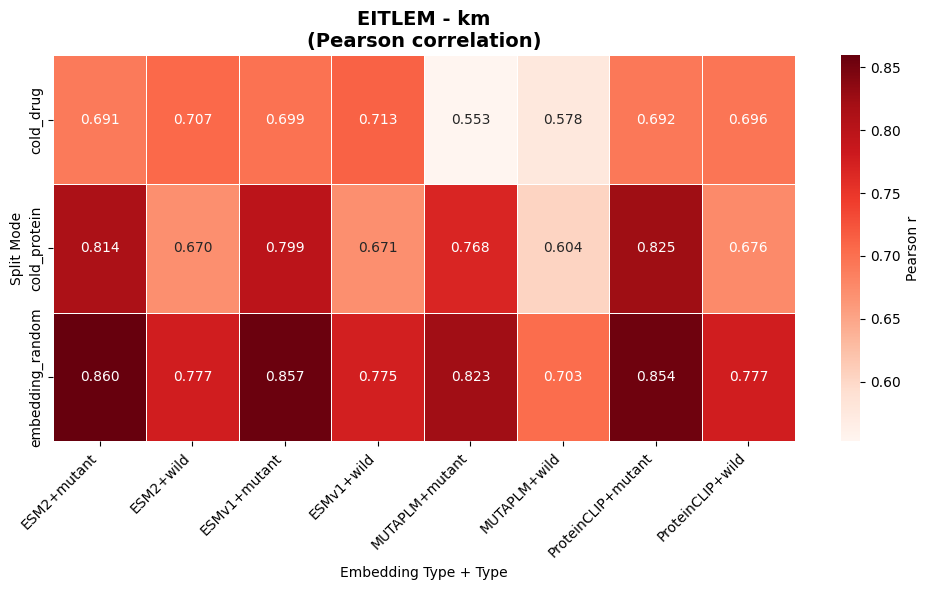

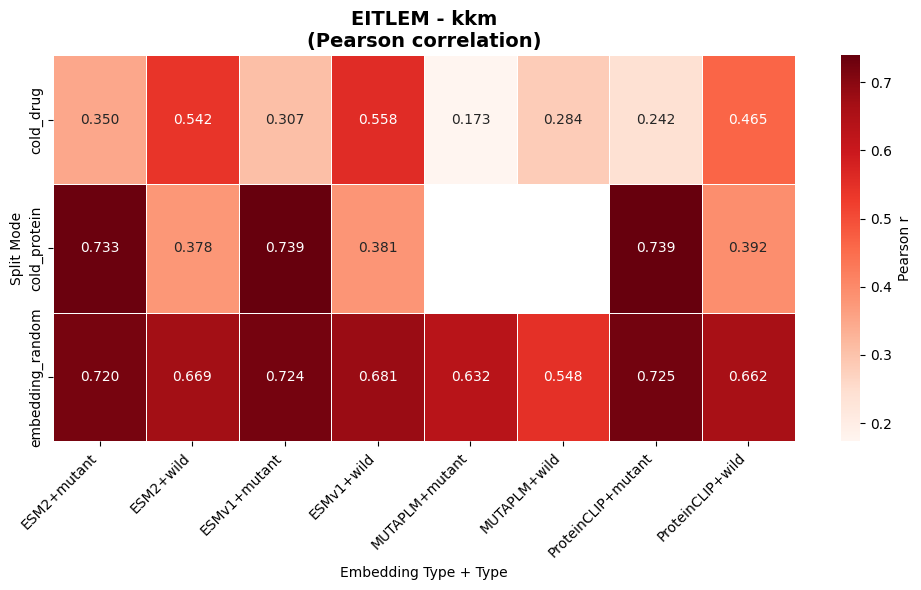

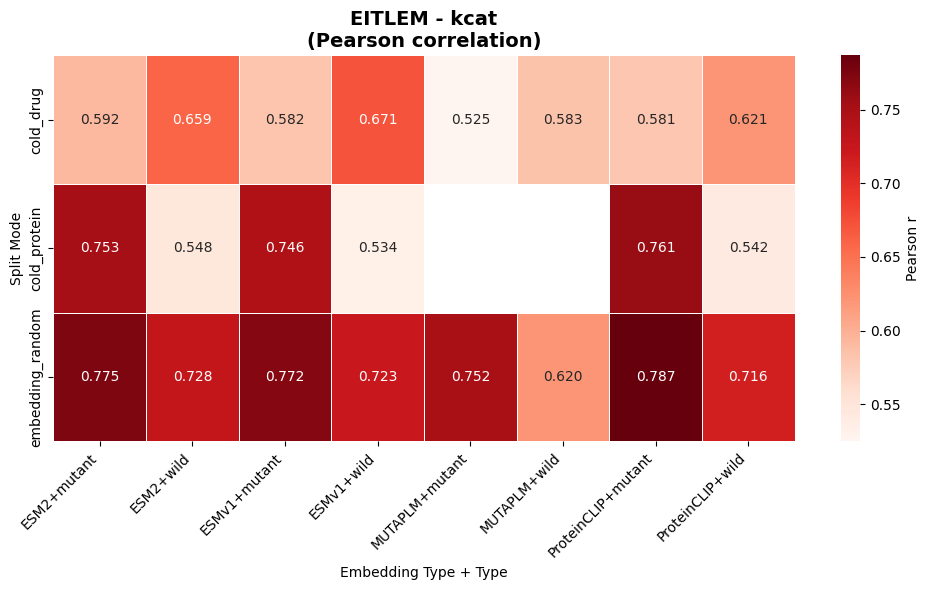

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

for kp in final_df["kinetic_parameter"].unique():
    sub = final_df[final_df["kinetic_parameter"] == kp].copy()
    sub["embedding_type"] = sub["embedding"] + "+" + sub["type"]

    heatmap_df = sub.pivot(index="split", columns="embedding_type", values="r")

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="Reds",
        linewidths=0.5,
        cbar_kws={"label": "Pearson r"}
    )

    ax.set_title(f"EITLEM - {kp}\n(Pearson correlation)", fontsize=14, weight="bold")
    ax.set_xlabel("Embedding Type + Type")
    ax.set_ylabel("Split Mode")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [51]:
df_concat = []

for dirpath, dirnames, filenames in os.walk('MPEK_predictions/'):
    for file in filenames:
        if 'pearson_summary.csv' in file or 'pearson_summary-checkpoint.csv' in file:
           continue
        full_path = os.path.join(dirpath, file)
        df = pd.read_csv(full_path)
        kinetic_parameter = file.split('_')[0]
        embedding         = file.split('_')[1]
        split             = "_".join(file.split('_')[2:4])
        
        if kinetic_parameter == 'kkm':
           label = 'km'
        else:
            label = kinetic_parameter
            
        print(file)
        
        out = (
                df.groupby("Type")
                  .apply(lambda g: pd.Series({
                  "r": pearsonr(g["Label"], g[label]).statistic,
                  "pvalue": pearsonr(g["Label"], g[label]).pvalue,
                  "n": len(g),
                  "kinetic_parameter" : kinetic_parameter,
                  "embedding"         : embedding,
                  "split"             : split
                  }))
                  .reset_index()
        )
        df_concat.append(out)

km_ProteinCLIP_cold_drug_predictions.csv
km_ProteinCLIP_cold_protein_predictions.csv
km_ProteinCLIP_embedding_random_predictions.csv
km_ESMv1_cold_drug_predictions.csv
km_ESMv1_cold_protein_predictions.csv
km_ESMv1_embedding_random_predictions.csv
km_ESM2_cold_drug_predictions.csv
km_ESM2_cold_protein_predictions.csv
km_ESM2_embedding_random_predictions.csv
km_MUTAPLM_cold_drug_predictions.csv
km_MUTAPLM_cold_protein_predictions.csv
km_MUTAPLM_embedding_random_predictions.csv
kcat_ProteinCLIP_cold_drug_predictions.csv
kcat_ProteinCLIP_cold_protein_predictions.csv
kcat_ProteinCLIP_embedding_random_predictions.csv
kcat_ESMv1_cold_drug_predictions.csv
kcat_ESMv1_cold_protein_predictions.csv
kcat_ESMv1_embedding_random_predictions.csv
kcat_ESM2_cold_drug_predictions.csv
kcat_ESM2_cold_protein_predictions.csv
kcat_ESM2_embedding_random_predictions.csv
kcat_MUTAPLM_cold_drug_predictions.csv
kcat_MUTAPLM_cold_protein_predictions.csv
kcat_MUTAPLM_embedding_random_predictions.csv


In [53]:
final_df = pd.concat(df_concat, ignore_index=True)
final_df["embedding_type"] = final_df["embedding"] + "+" + final_df["Type"]
sub = final_df[final_df["kinetic_parameter"] == "kcat"].copy()
sub["embedding_type"] = sub["embedding"] + "+" + sub["Type"]

heatmap_df = sub.pivot(
    index="split",
    columns="embedding_type",
    values="r"
)

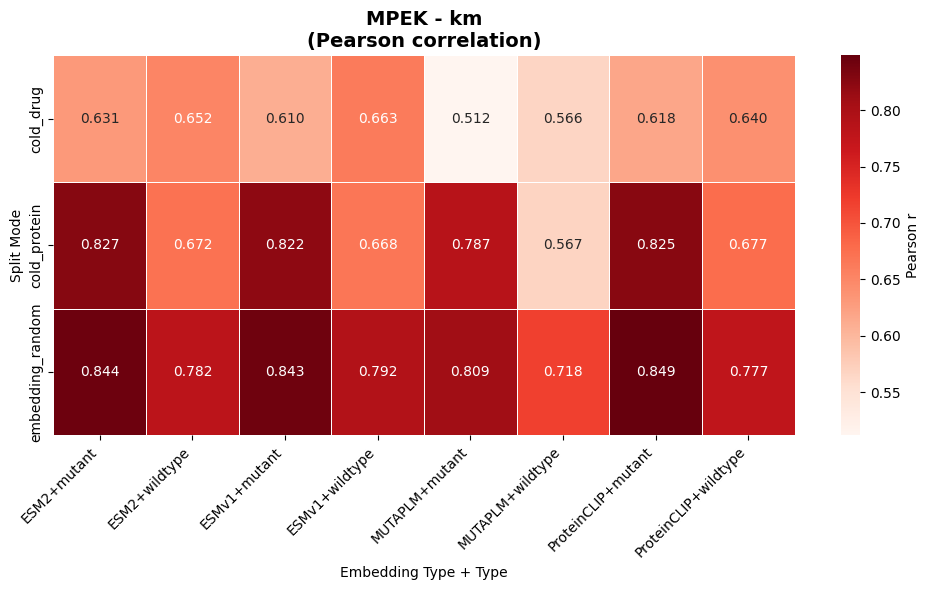

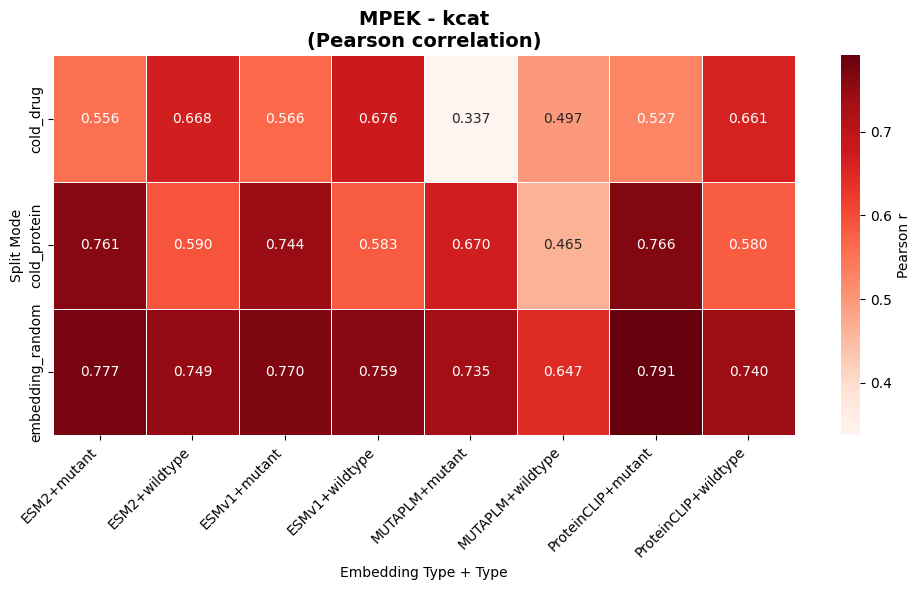

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

for kp in final_df["kinetic_parameter"].unique():
    sub = final_df[final_df["kinetic_parameter"] == kp].copy()
    sub["embedding_type"] = sub["embedding"] + "+" + sub["Type"]

    heatmap_df = sub.pivot(index="split", columns="embedding_type", values="r")

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="Reds",
        linewidths=0.5,
        cbar_kws={"label": "Pearson r"}
    )

    ax.set_title(f"MPEK - {kp}\n(Pearson correlation)", fontsize=14, weight="bold")
    ax.set_xlabel("Embedding Type + Type")
    ax.set_ylabel("Split Mode")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [19]:
df_concat = []

for dirpath, dirnames, filenames in os.walk('./catpred_predictions/'):
    for file in filenames:
        if 'pearson_summary.csv' in file or 'pearson_summary_embedding_random.csv' in file or 'predictions.csv' in file or 'kd_inhouse_prediction2_ESM2.csv' in file:
           continue
        # if file.startswith('kd'):
        #     continue
            
        print(file)
        print(dirpath)
        full_path = os.path.join(dirpath, file)
        df = pd.read_csv(full_path)
        kinetic_parameter = file.split('_')[0]
        embedding         = file.split('_')[1]
        split             = "_".join(file.split('_')[2:4])
        
        if kinetic_parameter == 'kkm':
           label = 'km'
        else:
            label = kinetic_parameter
            
        print(file)
        
        out = (
                pd.DataFrame({
                  "r": pearsonr(df["Label"], df[label]).statistic,
                  "pvalue": pearsonr(g["Label"], g[label]).pvalue,
                  "n": len(g),
                  "kinetic_parameter" : kinetic_parameter,
                  "embedding"         : embedding,
                  "split"             : split
                  }).reset_index()
        )
        df_concat.append(out)

In [3]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

df_concat = []
skip_files = {
    'pearson_summary.csv',
    'pearson_summary_embedding_random.csv',
    'predictions.csv',
    'kd_inhouse_prediction2_ESM2.csv'
}
for dirpath, dirnames, filenames in os.walk('./catpred_predictions/'):
    for file in filenames:
        if file in skip_files:
            continue

        full_path = os.path.join(dirpath, file)
        print(f"\nProcessing: {full_path}")

        try:
            df = pd.read_csv(full_path)

            parts = file.split('_')
            if len(parts) < 4:
                print(f"Skipping {file}: filename does not have expected format")
                continue

            kinetic_parameter = parts[0]
            embedding = parts[1]
            split = "_".join(parts[2:4])

            label = 'km' if kinetic_parameter == 'kkm' else kinetic_parameter

            if "Label" not in df.columns:
                print(f"Skipping {file}: missing 'Label' column")
                continue

            if label not in df.columns:
                print(f"Skipping {file}: missing '{label}' column")
                continue

            tmp = df[["Label", label]].dropna()

            if len(tmp) < 2:
                print(f"Skipping {file}: fewer than 2 valid rows")
                continue

            r, p = pearsonr(tmp["Label"], tmp[label])

            out = pd.DataFrame([{
                "r": r,
                "pvalue": p,
                "n": len(tmp),
                "kinetic_parameter": kinetic_parameter,
                "embedding": embedding,
                "split": split,
                "file": file,
                "dirpath": dirpath
            }])

            df_concat.append(out)
            print(f"Added result for {file}")

        except Exception as e:
            print(f"ERROR reading {full_path}: {e}")

if len(df_concat) == 0:
    print("No valid files were processed.")
    final_df = pd.DataFrame()
else:
    final_df = pd.concat(df_concat, ignore_index=True)


Processing: ./catpred_predictions/km/ProteinCLIP/cold_drug/km_ProteinCLIP_cold_drug_predictions.csv
Added result for km_ProteinCLIP_cold_drug_predictions.csv

Processing: ./catpred_predictions/km/ProteinCLIP/cold_protein/km_ProteinCLIP_cold_protein_predictions.csv
Added result for km_ProteinCLIP_cold_protein_predictions.csv

Processing: ./catpred_predictions/km/ProteinCLIP/embedding_random/km_ProteinCLIP_embedding_random_predictions.csv
Added result for km_ProteinCLIP_embedding_random_predictions.csv

Processing: ./catpred_predictions/km/ESMv1/cold_drug/km_ESMv1_cold_drug_predictions.csv
Added result for km_ESMv1_cold_drug_predictions.csv

Processing: ./catpred_predictions/km/ESMv1/cold_protein/km_ESMv1_cold_protein_predictions.csv
Added result for km_ESMv1_cold_protein_predictions.csv

Processing: ./catpred_predictions/km/ESMv1/embedding_random/km_ESMv1_embedding_random_predictions.csv
Added result for km_ESMv1_embedding_random_predictions.csv

Processing: ./catpred_predictions/km/ES

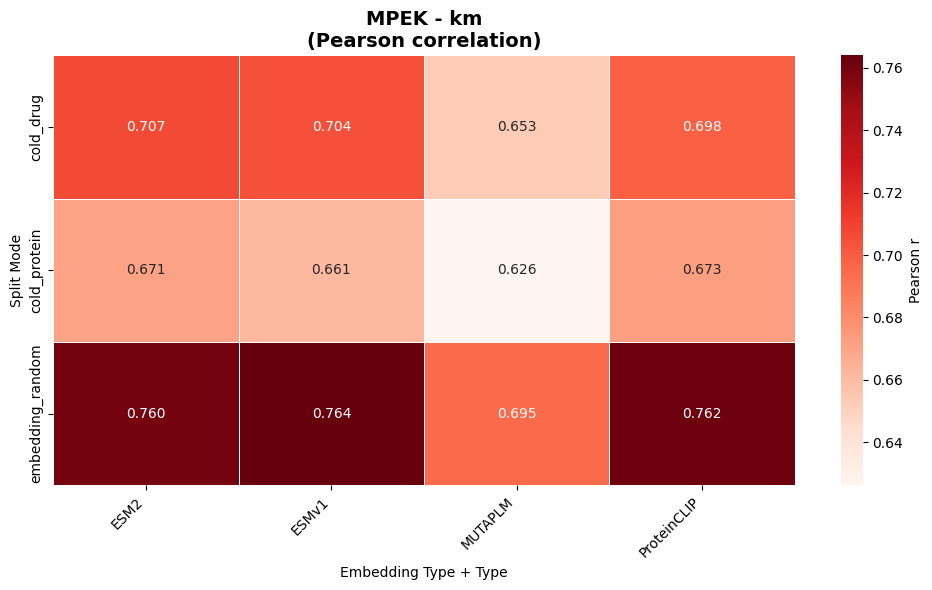

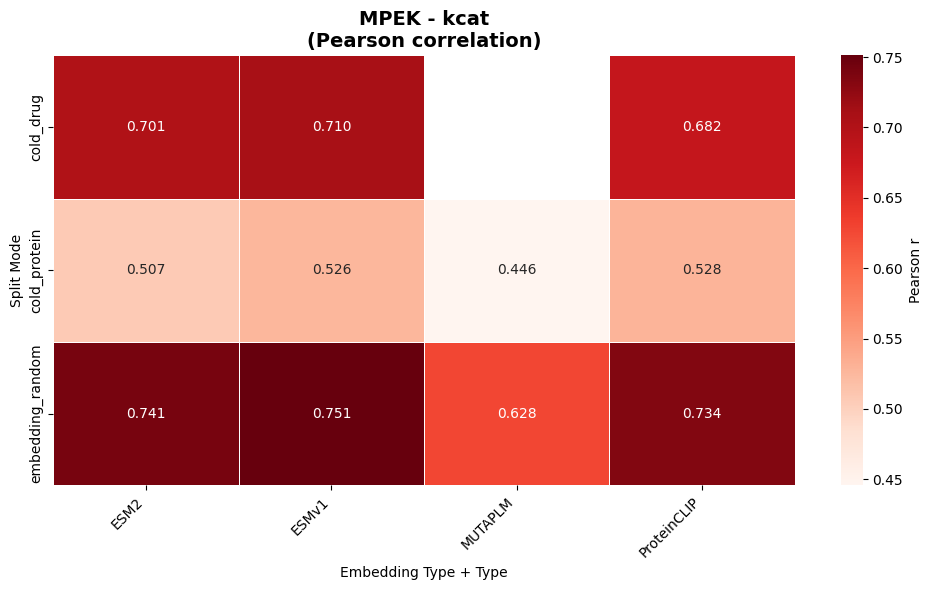

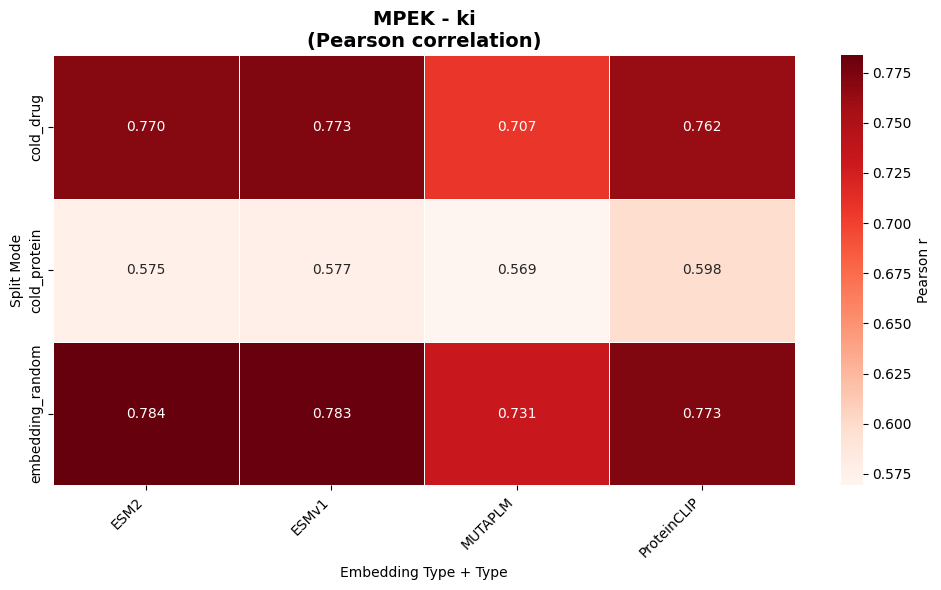

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

for kp in final_df["kinetic_parameter"].unique():
    sub = final_df[final_df["kinetic_parameter"] == kp].copy()

    heatmap_df = sub.pivot(index="split", columns="embedding", values="r")

    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        heatmap_df,
        annot=True,
        fmt=".3f",
        cmap="Reds",
        linewidths=0.5,
        cbar_kws={"label": "Pearson r"}
    )

    ax.set_title(f"MPEK - {kp}\n(Pearson correlation)", fontsize=14, weight="bold")
    ax.set_xlabel("Embedding Type + Type")
    ax.set_ylabel("Split Mode")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [4]:
df_concat = []

for dirpath, dirnames, filenames in os.walk('../retrain_inhouse/'):
    for file in filenames:
        if 'pearson_summary.csv' in file or 'pearson_summary-checkpoint.csv' in file:
           continue
        full_path = os.path.join(dirpath, file)
        df = pd.read_csv(full_path)
        kinetic_parameter = file.split('_')[0]
        embedding         = file.split('_')[1]
        split             = "_".join(file.split('_')[2:4])
        
        if kinetic_parameter == 'kkm':
           label = 'km'
        else:
            label = kinetic_parameter
            
        print(file)
        
        out = (
                df.groupby("Type")
                  .apply(lambda g: pd.Series({
                  "r": pearsonr(g["Label"], g[label]).statistic,
                  "pvalue": pearsonr(g["Label"], g[label]).pvalue,
                  "n": len(g),
                  "kinetic_parameter" : kinetic_parameter,
                  "embedding"         : embedding,
                  "split"             : split
                  }))
                  .reset_index()
        )
        df_concat.append(out)

,r,pvalue,n,kinetic_parameter,embedding,split,file,dirpath
0,0.698390,0.000000e+00,8420,km,ProteinCLIP,cold_drug,km_ProteinCLIP_cold_drug_predictions.csv,./catpred_predictions/km/ProteinCLIP/cold_drug
1,0.672821,0.000000e+00,8716,km,ProteinCLIP,cold_protein,km_ProteinCLIP_cold_protein_predictions.csv,./catpred_predictions/km/ProteinCLIP/cold_protein
2,0.762170,0.000000e+00,4118,km,ProteinCLIP,embedding_random,km_ProteinCLIP_embedding_random_predictions.csv,./catpred_predictions/km/ProteinCLIP/embedding...
3,0.704488,0.000000e+00,8420,km,ESMv1,cold_drug,km_ESMv1_cold_drug_predictions.csv,./catpred_predictions/km/ESMv1/cold_drug
4,0.661435,0.000000e+00,8716,km,ESMv1,cold_protein,km_ESMv1_cold_protein_predictions.csv,./catpred_predictions/km/ESMv1/cold_protein
5,0.764041,0.000000e+00,4118,km,ESMv1,embedding_random,km_ESMv1_embedding_random_predictions.csv,./catpred_predictions/km/ESMv1/embedding_random
6,0.706794,0.000000e+00,8420,km,ESM2,cold_drug,km_ESM2_cold_drug_predictions.csv,./catpred_predictions/km/ESM2/cold_drug
7,0.670931,0.000000e+00,8716,km,ESM2,cold_protein,km_ESM2_cold_protein_predictions.csv,./catpred_predictions/km/ESM2/cold_protein
8,0.759892,0.000000e+00,4118,km,ESM2,embedding_random,km_ESM2_embedding_random_predictions.csv,./catpred_predictions/km/ESM2/embedding_random
9,0.653165,0.000000e+00,8420,km,MUTAPLM,cold_drug,km_MUTAPLM_cold_drug_predictions.csv,./catpred_predictions/km/MUTAPLM/cold_drug


In [22]:
import os
import pandas as pd

root = "./catpred_predictions/"

n_dirs = 0
n_files = 0
n_csv = 0

for dirpath, dirnames, filenames in os.walk(root):
    n_dirs += 1
    print(f"\nDIR: {dirpath}")
    print("FILES:", filenames)

    for file in filenames:
        n_files += 1
        if file.endswith(".csv"):
            n_csv += 1
            print("  CSV FOUND ->", os.path.join(dirpath, file))

print("\nSUMMARY")
print("dirs visited:", n_dirs)
print("files seen:", n_files)
print("csv files seen:", n_csv)


DIR: ./catpred_predictions/
FILES: ['pearson_summary_embedding_random.csv', 'pearson_summary.csv']
  CSV FOUND -> ./catpred_predictions/pearson_summary_embedding_random.csv
  CSV FOUND -> ./catpred_predictions/pearson_summary.csv

DIR: ./catpred_predictions/km
FILES: []

DIR: ./catpred_predictions/km/ProteinCLIP
FILES: []

DIR: ./catpred_predictions/km/ProteinCLIP/cold_drug
FILES: ['predictions.csv', 'km_ProteinCLIP_cold_drug_predictions.csv']
  CSV FOUND -> ./catpred_predictions/km/ProteinCLIP/cold_drug/predictions.csv
  CSV FOUND -> ./catpred_predictions/km/ProteinCLIP/cold_drug/km_ProteinCLIP_cold_drug_predictions.csv

DIR: ./catpred_predictions/km/ProteinCLIP/cold_protein
FILES: ['km_ProteinCLIP_cold_protein_predictions.csv', 'predictions.csv']
  CSV FOUND -> ./catpred_predictions/km/ProteinCLIP/cold_protein/km_ProteinCLIP_cold_protein_predictions.csv
  CSV FOUND -> ./catpred_predictions/km/ProteinCLIP/cold_protein/predictions.csv

DIR: ./catpred_predictions/km/ProteinCLIP/embeddi